# 🧠 AI Document Classifier — ML Training Notebook

**Goal:** Train the best possible classifier to categorise government PDF documents into 6 departments.

**Approach:** Compare 5 algorithms on the same data and automatically pick the winner.

**Output:** Two `.pkl` files in `notebooks/models/` — copy to `backend/training/models/` to deploy.

---

### 📋 Notebook Flow

| Step | What happens |
|------|-------------|
| 1 | Folder structure |
| 2 | Install and import dependencies |
| 3 | Import extractor.py from project |
| 4 | Download real government PDFs |
| 5 | Extract and clean text from PDFs |
| 6 | Load synthetic training data |
| 7 | Combine datasets and visualise |
| 8 | Preprocess and remove cross-dept noise |
| 9 | Train ALL 5 models and compare |
| 10 | Evaluate winner: accuracy, confusion matrix, CV, confidence |
| 11 | Save model files |
| 12 | Quick smoke test |

> **Always run:** `Kernel → Restart & Run All` — never run individual cells after editing.

In [1]:
print("ML Classifier Training Notebook")

ML Classifier Training Notebook


---
## Step 1 — Folder Structure

Creates `models/` and `data/` directories inside the notebooks folder.
- `models/` — trained `.pkl` files and evaluation charts saved here
- `data/<dept>/` — downloaded PDFs cached here (re-run safely skips already-downloaded files)

In [2]:
import os

DEPARTMENTS = [
    'Finance',
    'Human Resources',
    'Legal & Regulatory',
    'Licensing & Compliance',
    'IT & Technology',
    'Operations',
]

os.makedirs('models', exist_ok=True)
for dept in DEPARTMENTS:
    os.makedirs(f'data/{dept}', exist_ok=True)

print('✅ Folder structure created:')
print('   notebooks/')
print('   ├── models/   ← trained .pkl files saved here')
print('   └── data/')
for dept in DEPARTMENTS:
    print(f'       ├── {dept}/')

✅ Folder structure created:
   notebooks/
   ├── models/   ← trained .pkl files saved here
   └── data/
       ├── Finance/
       ├── Human Resources/
       ├── Legal & Regulatory/
       ├── Licensing & Compliance/
       ├── IT & Technology/
       ├── Operations/


---
## Step 2 — Install and Import Dependencies

**Make sure your `.venv` is active in VS Code before running.**

All packages should already be installed from `requirements.txt`. This cell checks and installs any that are missing.

**Why each package:**
- `scikit-learn` — TF-IDF vectorizer plus all 5 classifiers (LR, SVM, NB, RF, Voting Ensemble)
- `pdfplumber / PyPDF2` — dual-library PDF extraction matching your production extractor.py
- `pandas / numpy` — data manipulation
- `matplotlib / seaborn` — evaluation charts
- `joblib` — efficient model file serialisation

In [3]:
import subprocess, sys

packages = [
    'pdfplumber', 'PyPDF2', 'scikit-learn', 'requests',
    'matplotlib', 'seaborn', 'pandas', 'numpy', 'joblib'
]

for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages available')

Installing scikit-learn...
✅ All packages available


In [4]:
# Core
import os, sys, re, json, requests, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

# ML — all 5 classifiers we will compare
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.naive_bayes             import ComplementNB
from sklearn.ensemble                import VotingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection         import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics                 import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline                import Pipeline

# PDF
import pdfplumber
import PyPDF2

# Add project root to path so extractor.py import resolves
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('✅ All imports done')
print(f'   Project root: {PROJECT_ROOT}')

✅ All imports done
   Project root: d:\Py_Projects\ai-classifier


---
## Step 3 — Import Your extractor.py

Reuses your production PDF extractor so training data is extracted **the exact same way** as in production. If the import fails, falls back to a built-in extractor using the same dual-library logic.

**Important:** Open this notebook from the project root `D:\Py_Projects\ai-classifier\` — not from inside `notebooks\`. This is required for `from backend.classifier.extractor` to resolve.

In [5]:
# Try importing your project extractor
try:
    from backend.classifier.extractor import PDFExtractor
    extractor = PDFExtractor()
    USE_PROJECT_EXTRACTOR = True
    print('✅ Using project extractor.py (PDFExtractor)')
except ImportError as e:
    print(f'⚠️  Could not import project extractor: {e}')
    print('   Falling back to built-in extraction (same logic)')
    USE_PROJECT_EXTRACTOR = False

def extract_text_fallback(pdf_path: str, max_chars: int = 3000) -> str:
    """Dual-library extraction — mirrors extractor.py"""
    text = ''
    try:                          # pdfplumber first (better layout handling)
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                t = page.extract_text()
                if t:
                    text += t + ' '
                if len(text) >= max_chars:
                    break
    except Exception:
        pass
    if len(text.strip()) < 100:   # fallback to PyPDF2
        try:
            with open(pdf_path, 'rb') as f:
                reader = PyPDF2.PdfReader(f)
                for page in reader.pages:
                    t = page.extract_text()
                    if t:
                        text += t + ' '
                    if len(text) >= max_chars:
                        break
        except Exception:
            pass
    return text[:max_chars].strip()

def extract_text(pdf_path: str, max_chars: int = 3000) -> str:
    if USE_PROJECT_EXTRACTOR:
        try:
            return extractor.extract(pdf_path)[:max_chars]
        except Exception:
            pass
    return extract_text_fallback(pdf_path, max_chars)

print('✅ Text extraction function ready')

⚠️  Could not import project extractor: cannot import name 'PDFExtractor' from 'backend.classifier.extractor' (d:\Py_Projects\ai-classifier\backend\classifier\extractor.py)
   Falling back to built-in extraction (same logic)
✅ Text extraction function ready


---
## Step 4 — Download Real Government PDFs

Downloads publicly available Australian government PDFs. These add authentic document structure and phrasing alongside the synthetic data.

**Already downloaded?** The cell skips any file > 5KB — safe to re-run.

**Download fails?** The notebook continues gracefully using synthetic data only for that department, which is sufficient for training.

In [6]:
# Verified working URLs as of 2025/2026
GOV_DOCS = {

    'Finance': [
        {
            'name': 'Commonwealth_Procurement_Rules_2024',
            'url':  'https://www.finance.gov.au/sites/default/files/2024-06/Commonwealth_Procurement_Rules-1-July-2024.pdf',
            'desc': 'Commonwealth Procurement Rules July 2024'
        },
        {
            'name': 'Commonwealth_Procurement_Rules_2023',
            'url':  'https://www.finance.gov.au/sites/default/files/2023-06/Commonwealth%20Procurement%20Rules%20-%2013%20June%202023.pdf',
            'desc': 'Commonwealth Procurement Rules June 2023'
        },
        {
            'name': 'ANAO_Financial_Statements_Report_2006',
            'url':  'https://www.anao.gov.au/sites/default/files/ANAO_Report_2006-2007_15.pdf',
            'desc': 'ANAO Audits of Financial Statements'
        },
    ],

    'Human Resources': [
        {
            'name': 'APS_Workforce_Strategy_2025',
            'url':  'https://www.apsc.gov.au/sites/default/files/2021-03/APS_Workforce_strategy_2025.pdf',
            'desc': 'APS Workforce Strategy 2025'
        },
        {
            'name': 'APS_Workforce_Planning_Guide',
            'url':  'https://www.apsc.gov.au/sites/default/files/2023-04/APS%20Centre%20of%20Excellence%20-%20Workforce%20Planning%20Guide%20-%20Accessibility.pdf',
            'desc': 'APS Workforce Planning Guide'
        },
        {
            'name': 'APS_HR_Pathways_Framework',
            'url':  'https://www.apsc.gov.au/sites/default/files/2021-07/APS%20HR%20Pathways%20to%20Professionalisation%20Framework.pdf',
            'desc': 'APS HR Pathways Framework'
        },
    ],

    'Legal & Regulatory': [
        {
            'name': 'OAIC_Consolidated_APP_Guidelines',
            'url':  'https://www.oaic.gov.au/__data/assets/pdf_file/0019/258121/Consolidated-APP-guidelines.pdf',
            'desc': 'OAIC Australian Privacy Principles Guidelines'
        },
        {
            'name': 'OAIC_APP_Chapter_1',
            'url':  'https://www.oaic.gov.au/__data/assets/pdf_file/0004/1210/app-guidelines-chapter-1-v1.1.pdf',
            'desc': 'OAIC APP Guidelines Chapter 1'
        },
        {
            'name': 'OAIC_APP_Chapter_11',
            'url':  'https://www.oaic.gov.au/__data/assets/pdf_file/0018/1287/app-guidelines-chapter-11-v1.2.pdf',
            'desc': 'OAIC APP Guidelines Chapter 11'
        },
    ],

    'Licensing & Compliance': [
        {
            'name': 'OAIC_Guidelines_for_Developing_Codes',
            'url':  'https://www.oaic.gov.au/__data/assets/pdf_file/0032/48758/Guidelines-for-developing-codes-2023-Updated.pdf',
            'desc': 'OAIC Guidelines for developing privacy codes 2023'
        },
        {
            'name': 'OAIC_Privacy_Community_Attitudes_2023',
            'url':  'https://www.oaic.gov.au/__data/assets/pdf_file/0025/74482/OAIC-Australian-Community-Attitudes-to-Privacy-Survey-2023.pdf',
            'desc': 'Australian Community Attitudes to Privacy Survey 2023'
        },
        {
            'name': 'AGS_Commonwealth_Procurement_Factsheet',
            'url':  'https://www.ags.gov.au/sites/default/files/2021-02/Fact_sheet_No_7_03.pdf',
            'desc': 'AGS Commonwealth Procurement Rules factsheet'
        },
    ],

    'IT & Technology': [
        {
            'name': 'ASD_Essential_Eight_Maturity_Model_Nov2023',
            'url':  'https://www.cyber.gov.au/sites/default/files/2023-11/PROTECT%20-%20Essential%20Eight%20Maturity%20Model%20(November%202023).pdf',
            'desc': 'ASD Essential Eight Maturity Model November 2023'
        },
        {
            'name': 'ASD_Essential_Eight_Explained_Nov2023',
            'url':  'https://www.cyber.gov.au/sites/default/files/2023-11/PROTECT%20-%20Essential%20Eight%20Explained%20(November%202023).pdf',
            'desc': 'ASD Essential Eight Explained November 2023'
        },
        {
            'name': 'NIST_Cybersecurity_Framework_v1_1',
            'url':  'https://nvlpubs.nist.gov/nistpubs/cswp/nist.cswp.04162018.pdf',
            'desc': 'NIST Cybersecurity Framework Version 1.1'
        },
    ],

    'Operations': [
        {
            'name': 'Commonwealth_Procurement_Rules_2025',
            'url':  'https://www.finance.gov.au/sites/default/files/2025-10/Commonwealth-Procurement-Rules-2025.pdf',
            'desc': 'Commonwealth Procurement Rules November 2025'
        },
        {
            'name': 'APS_Data_Digital_Cyber_Workforce_Plan',
            'url':  'https://www.dataanddigital.gov.au/sites/default/files/documents/2025-10/APS%20Data,%20Digital%20and%20Cyber%20Workforce%20Plan%202025-30_v1.1.pdf',
            'desc': 'APS Data Digital Cyber Workforce Plan 2025-30'
        },
        {
            'name': 'NIST_SP800_61r3_Incident_Response',
            'url':  'https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-61r3.pdf',
            'desc': 'NIST SP 800-61r3 Incident Handling Guide'
        },
    ],
}

print('✅ Document URLs defined')
total = sum(len(v) for v in GOV_DOCS.values())
print(f'   {total} documents across {len(GOV_DOCS)} departments')

✅ Document URLs defined
   18 documents across 6 departments


In [7]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (research/training)'}
download_results = {dept: [] for dept in DEPARTMENTS}

for dept, docs in GOV_DOCS.items():
    print(f'📂 {dept}')
    for doc in docs:
        save_path = f"data/{dept}/{doc['name']}.pdf"
        if os.path.exists(save_path) and os.path.getsize(save_path) > 5000:
            print(f"   ✅ Already have: {doc['name']}")
            download_results[dept].append(save_path)
            continue
        try:
            resp = requests.get(doc['url'], headers=HEADERS, timeout=30, stream=True)
            content_type = resp.headers.get('content-type', '').lower()
            if resp.status_code == 200 and ('pdf' in content_type or resp.url.endswith('.pdf')):
                with open(save_path, 'wb') as f:
                    for chunk in resp.iter_content(8192):
                        f.write(chunk)
                size_kb = os.path.getsize(save_path) // 1024
                print(f"   ✅ Downloaded: {doc['name']} ({size_kb}KB)")
                download_results[dept].append(save_path)
            else:
                print(f"   ⚠️  Skipped (status {resp.status_code}): {doc['name']}")
        except Exception as e:
            print(f"   ❌ Failed: {doc['name']} — {str(e)[:60]}")

print('\n' + '─'*50)
print('📊 Download Summary:')
for dept, paths in download_results.items():
    print(f'   {dept}: {len(paths)} PDFs')

📂 Finance
   ✅ Already have: Commonwealth_Procurement_Rules_2024
   ✅ Already have: Commonwealth_Procurement_Rules_2023
   ✅ Already have: ANAO_Financial_Statements_Report_2006
📂 Human Resources
   ✅ Already have: APS_Workforce_Strategy_2025
   ✅ Already have: APS_Workforce_Planning_Guide
   ✅ Already have: APS_HR_Pathways_Framework
📂 Legal & Regulatory
   ✅ Already have: OAIC_Consolidated_APP_Guidelines
   ✅ Already have: OAIC_APP_Chapter_1
   ✅ Already have: OAIC_APP_Chapter_11
📂 Licensing & Compliance
   ⚠️  Skipped (status 403): OAIC_Guidelines_for_Developing_Codes
   ✅ Already have: OAIC_Privacy_Community_Attitudes_2023
   ✅ Already have: AGS_Commonwealth_Procurement_Factsheet
📂 IT & Technology
   ✅ Already have: ASD_Essential_Eight_Maturity_Model_Nov2023
   ✅ Already have: ASD_Essential_Eight_Explained_Nov2023
   ✅ Already have: NIST_Cybersecurity_Framework_v1_1
📂 Operations
   ✅ Already have: Commonwealth_Procurement_Rules_2025
   ✅ Already have: APS_Data_Digital_Cyber_Workforce

---
## Step 5 — Extract Text From Downloaded PDFs

Extracts text from each PDF and splits into **overlapping 200-word chunks**. Each chunk becomes one training sample.

**Why chunk?** A 50-page PDF as a single sample is hard to classify. 200-word chunks represent realistic document excerpt lengths.

**Why overlap (50 words)?** Prevents important phrases from being split at chunk boundaries.

**Boilerplate removal:** Every government PDF has identical Creative Commons footer text. This appears across ALL departments and would train the model on noise — it is stripped before chunking.

**Cap at 8 chunks per PDF** so one large document does not dominate the training set.

In [8]:
# Every government PDF contains identical footer/header text.
# This text appears in ALL departments and adds zero classification signal.
# Strip it before chunking.

BOILERPLATE_PHRASES = [
    'creative commons', 'attribution', 'creativecommons.org',
    'this publication', 'all rights reserved', 'copyright',
    'licensed under', 'licence visit', 'licence deed',
    'reproduction and rights', 'please contact',
    'enquiries regarding', 'enquiries concerning',
    'acknowledgement', 'acknowledgment', 'traditional owners',
    'custodians', 'elders past', 'elders present',
    'isbn', 'issn', 'doi:', 'www.', 'http',
]

def remove_boilerplate(text: str) -> str:
    """Remove PDF footer/header boilerplate that appears across all departments."""
    lines = text.split('\n')
    clean = []
    for line in lines:
        ll = line.lower().strip()
        if any(phrase in ll for phrase in BOILERPLATE_PHRASES):
            continue
        if len(line.strip()) < 20:          # skip short lines (page numbers, headers)
            continue
        if line.strip().replace(' ', '').isdigit():   # skip pure number lines
            continue
        clean.append(line)
    return ''.join(clean)

print('✅ Boilerplate removal function ready')

✅ Boilerplate removal function ready


In [9]:
real_data = []

for dept, paths in download_results.items():
    print(f'📂 Extracting: {dept}')
    for pdf_path in paths:
        try:
            text = extract_text(pdf_path, max_chars=6000)
            text = remove_boilerplate(text)      # strip Creative Commons etc.

            if len(text.strip()) < 100:
                print(f'   ⚠️  Too little text: {os.path.basename(pdf_path)}')
                continue

            # Split into overlapping 200-word chunks
            words    = text.split()
            chunk_sz = 200    # words per chunk
            overlap  = 50     # overlap to avoid cutting phrases at boundaries
            chunks   = []

            for i in range(0, max(1, len(words) - chunk_sz + 1), chunk_sz - overlap):
                chunk = ' '.join(words[i:i + chunk_sz])
                if len(chunk.split()) >= 80:
                    chunks.append(chunk)

            chunks = chunks[:8]    # cap per PDF to avoid one doc dominating

            for chunk in chunks:
                real_data.append({'text': chunk, 'label': dept, 'source': 'real_gov_pdf'})

            print(f'   ✅ {os.path.basename(pdf_path)} → {len(chunks)} chunks')

        except Exception as e:
            print(f'   ❌ Error: {os.path.basename(pdf_path)} — {e}')

print(f'✅ Total real samples extracted: {len(real_data)}')
df_real = pd.DataFrame(real_data) if real_data else pd.DataFrame(columns=['text','label','source'])
if not df_real.empty:
    print(df_real['label'].value_counts().to_string())
else:
    print('   (No real PDFs extracted — will train on synthetic only)')

📂 Extracting: Finance
   ✅ Commonwealth_Procurement_Rules_2024.pdf → 4 chunks
   ✅ Commonwealth_Procurement_Rules_2023.pdf → 4 chunks
   ✅ ANAO_Financial_Statements_Report_2006.pdf → 2 chunks
📂 Extracting: Human Resources
   ✅ APS_Workforce_Strategy_2025.pdf → 4 chunks
   ✅ APS_Workforce_Planning_Guide.pdf → 1 chunks
   ✅ APS_HR_Pathways_Framework.pdf → 4 chunks
📂 Extracting: Legal & Regulatory
   ✅ OAIC_Consolidated_APP_Guidelines.pdf → 4 chunks
   ✅ OAIC_APP_Chapter_1.pdf → 5 chunks
   ✅ OAIC_APP_Chapter_11.pdf → 5 chunks
📂 Extracting: Licensing & Compliance
   ✅ OAIC_Privacy_Community_Attitudes_2023.pdf → 1 chunks
   ✅ AGS_Commonwealth_Procurement_Factsheet.pdf → 4 chunks
📂 Extracting: IT & Technology
   ✅ ASD_Essential_Eight_Maturity_Model_Nov2023.pdf → 4 chunks
   ✅ ASD_Essential_Eight_Explained_Nov2023.pdf → 2 chunks
   ✅ NIST_Cybersecurity_Framework_v1_1.pdf → 4 chunks
📂 Extracting: Operations
   ✅ Commonwealth_Procurement_Rules_2025.pdf → 4 chunks
   ✅ APS_Data_Digital_Cyber_Wo

---
## Step 6 — High-Quality Government Synthetic Data

**Why synthetic data?** Real PDFs gave only ~32 chunks — not enough to train reliably. These hand-written examples cover the full vocabulary range of each department:
- Finance: budget, appropriation, PGPA Act, accrual, acquittal
- Human Resources: APS leave, enterprise agreements, remuneration tribunal
- Legal & Regulatory: FOI, AAT, judicial review, natural justice
- Licensing & Compliance: licensee, fit and proper, show cause, ASIC, APRA
- IT & Technology: Essential Eight, patch, MFA, zero trust, SIEM
- Operations: fleet, sq metres, call centre, procurement thresholds, HVAC

**50 base samples per department** plus additional Operations samples added to fix recall issues in that department.

In [10]:
SYNTHETIC_DATA = {

'Finance': [
    # Budget & Appropriations
    "The department's total appropriation for the current financial year is $142.6 million, comprising $128.4 million in departmental funding and $14.2 million in administered appropriations. The forward estimates project a 3.2% increase over the next four years subject to mid-year economic and fiscal outlook adjustments.",
    "Budget estimates have been revised following the mid-year economic and fiscal outlook. Departmental expenses are forecast at $98.3 million with administered expenses of $45.7 million. Capital expenditure is budgeted at $12.4 million for infrastructure and systems upgrades.",
    "The appropriation bill authorises expenditure of $234 million for departmental operations. The Minister has approved expenditure under section 32 of the PGPA Act for urgent procurement requirements. Supplementary appropriation will be sought if expenditure exceeds the approved allocation.",
    "Forward year budget allocations reflect the government's fiscal consolidation strategy. Efficiency dividends of 1.5% have been applied to departmental operating budgets. Agencies are required to absorb price increases within existing allocations unless compelling justification is provided.",
    "The mid-year budget update reflects revised revenue forecasts based on updated economic parameters. GST revenue is projected at $78.4 billion, 2.1% below the original budget estimate. Company tax receipts have been revised upward following stronger than anticipated corporate profitability.",
    # Financial Statements
    "The financial statements have been prepared on an accrual basis in accordance with Australian Accounting Standards and the Public Governance Performance and Accountability (Financial Reporting) Rule 2015. The statements present fairly the financial position of the entity as at 30 June.",
    "The auditor's report confirms the financial statements comply with the PGPA Act and present fairly the financial performance of the entity. The audit found no material misstatements. Management has accepted all audit recommendations relating to internal controls over payables.",
    "Total assets of the entity stand at $456.7 million comprising property plant and equipment of $234.1 million, receivables of $45.3 million, and cash and cash equivalents of $23.8 million. Total liabilities are $178.4 million resulting in net assets of $278.3 million.",
    "Revenue from government was $189.4 million for the reporting period. Own source revenue comprising fees and charges totalled $23.6 million. Total comprehensive income was $4.2 million after depreciation and amortisation charges of $18.7 million.",
    "The entity recognised an impairment loss of $3.4 million on legacy IT assets following a review of useful economic lives. Depreciation policy applies straight-line method over asset useful lives ranging from 3 to 25 years depending on asset category.",
    # Procurement & Grants
    "The grants program disbursed $45.6 million to 234 recipient organisations during the financial year. All grants were awarded through competitive assessment processes consistent with the Commonwealth Grants Rules and Guidelines. Grant acquittals are required within 60 days of program completion.",
    "Procurement expenditure totalled $67.8 million comprising 234 contracts above the reporting threshold. Contracts valued above $80,000 have been published on AusTender. All procurement was conducted in accordance with the Commonwealth Procurement Rules.",
    "The entity's accounts payable balance of $12.4 million represents amounts outstanding to suppliers at 30 June. The average payment time was 12.3 days against the government target of 20 days. No significant aged creditors were outstanding at balance date.",
    "Revenue collected on behalf of government totalled $1.23 billion comprising taxation revenue of $987 million and non-taxation revenue of $243 million. Collections were remitted to the Official Public Account on a daily basis in accordance with section 74 of the PGPA Act.",
    "The entity's investment portfolio is managed consistent with the investment mandate approved by the Finance Minister. Investments are held in Commonwealth Government Securities and term deposits. The portfolio returned 4.2% for the financial year against a benchmark of 3.8%.",
    # Internal Controls & Audit
    "The internal audit program identified three medium-risk findings relating to accounts payable processing controls, travel expense management, and contract management practices. Management has committed to remediation by the end of Q2. The audit committee has noted the findings.",
    "The entity maintains a risk register identifying 24 financial risks. Key financial risks include appropriation sufficiency, foreign exchange exposure, and credit risk from grant recipients. The Chief Financial Officer reviews the risk register quarterly.",
    "Asset management procedures require all capital acquisitions above $10,000 to be recorded in the asset register. Physical verification of assets is conducted annually. Assets identified as surplus to requirements are disposed of through whole of government disposal arrangements.",
    "The fraud control plan has been updated to reflect current operational risks. Financial fraud risks include duplicate payments, fictitious vendors, and unauthorised payment alterations. Controls include system-based duplicate payment checking and segregation of duties in the payments process.",
    "The entity's cash management framework requires all cash holdings to be minimised through efficient collections and timely payments. Surplus cash is swept daily to the Official Public Account. The entity maintains a working capital facility for short-term liquidity requirements.",
    # Cost Recovery & Fees
    "The cost recovery model has been reviewed in accordance with the Australian Government Cost Recovery Guidelines. Full cost recovery is applied to regulatory services provided to industry. Fees have been updated to reflect actual cost of service delivery including overhead allocation.",
    "The entity recovered $34.5 million in costs from industry participants during the year. The cost recovery rate of 98.7% was consistent with the approved cost recovery implementation statement. Residual unfunded costs of $0.4 million relate to public good activities.",
    "Capital charging rates have been reviewed and updated to reflect current cost of capital parameters issued by the Department of Finance. Rates apply to all assets funded from appropriation. The charge is included in agency cost recovery calculations.",
    "The special account holds monies received for specific purposes as authorised by the special account instrument. Debits from the special account must be consistent with the purposes specified. The balance at 30 June was $8.7 million representing unspent funds for continuing projects.",
    "Finance reporting obligations under the PGPA Act require quarterly financial statements to be submitted to the Department of Finance by the 20th day following each quarter end. The entity has complied with all reporting obligations during the financial year.",
    # Economic & Fiscal Policy
    "The fiscal strategy aims to achieve underlying cash balance surpluses over the medium term. Net debt is projected to decline as a percentage of GDP over the forward estimates. The strategy provides a buffer against economic shocks while funding priority government commitments.",
    "Tax expenditures relating to concessional treatment of superannuation contributions are estimated at $19.7 billion annually. The expenditure tax base expenditure review is examining concessions to ensure they remain fit for purpose and cost effective.",
    "The contingent liability register records guarantees, indemnities and warranties provided by the entity. Material contingent liabilities total $234 million comprising legal claims and performance guarantees on infrastructure contracts. Provisions have been raised for probable outflows.",
    "The actuarial assessment of the defined benefit superannuation liability has been updated. The unfunded liability stands at $2.34 billion based on actuarial assumptions for investment returns, salary growth, and demographic factors. The liability is disclosed as a recognised provision.",
    "Foreign exchange risk is managed through natural hedging where possible. Residual foreign currency exposures above $500,000 are hedged using forward contracts approved by the Chief Financial Officer. The entity holds no speculative currency positions.",
    # Performance & Reporting
    "The annual performance statements report achievement against six key performance indicators established in the corporate plan. The entity achieved or exceeded targets for four indicators. Two indicators relating to processing times were below target due to demand exceeding forecasts.",
    "The entity's corporate plan sets out resource allocation across four priority programmes. Programme one receives 45% of total resources reflecting its central role in delivering government priorities. Resource allocation has been reviewed against programme performance outcomes.",
    "Whole of government financial reporting consolidates the financial statements of over 200 Commonwealth entities. The consolidated financial statements are audited by the Australian National Audit Office. Material adjustments are made to eliminate intra-government transactions and balances.",
    "The efficiency measure tracks cost per output across the entity's main programmes. Cost per output decreased by 3.4% compared to the prior year reflecting productivity improvements in processing operations. Efficiency gains have been reinvested in service quality improvements.",
    "The resource agreement between the entity and the portfolio minister specifies funding levels and expected outcomes for the budget year. The agreement is the primary accountability mechanism for departmental financial performance. Variations require ministerial approval.",
    # Treasury & Cash
    "Treasury management responsibilities include managing the entity's banking arrangements, short-term borrowing facilities, and investment of surplus funds. All banking is conducted through the Reserve Bank of Australia consistent with whole of government banking arrangements.",
    "The revolving credit facility provides access to $50 million to meet short-term operational cash flow requirements. The facility has not been drawn during the current year. Facility fees of $125,000 were expensed. The facility is renewed annually subject to satisfactory financial performance.",
    "Receivables of $23.4 million include $18.7 million in fees and charges receivable, $3.2 million in GST receivable from the ATO, and $1.5 million in other receivables. An allowance for doubtful debts of $1.2 million has been recognised based on historical collection experience.",
    "The entity maintains adequate insurance coverage for its operations including public liability, professional indemnity, and property insurance. Insurance is arranged through Comcover, the Australian Government's self-managed insurance fund. Annual premium was $456,000.",
    "Dividend payments to government totalled $12.4 million representing 30% of after-tax profit consistent with the dividend policy established in the entity's statement of corporate intent. The dividend was paid within 60 days of the financial year end.",
    # Grants Administration
    "Grant agreement management procedures require program officers to conduct annual performance assessments of all recipients receiving over $500,000. The assessment examines financial acquittal, milestone achievement, and value for money. Non-compliant recipients are placed on enhanced monitoring.",
    "The grants hub administers grants on behalf of 12 portfolio agencies. Processing volumes totalled 8,456 applications resulting in 2,341 grant awards. The average processing time was 34 days against the target of 40 days. User satisfaction rating was 87%.",
    "The community grants program disbursed $23.6 million to 145 community organisations. Priority was given to organisations in regional and remote areas experiencing service gaps. All grants were subject to competitive merit-based assessment by an independent advisory committee.",
    "Grant recipient acquittals are reviewed by program officers within 30 days of receipt. Material variations from approved budgets require written explanation and approval. Unspent grant funds must be returned unless an extension has been approved in writing by the delegate.",
    "The multiYear grant program provides funding certainty to peak bodies and research institutions over a three-year period. Total committed funding is $78.4 million. Annual performance milestones must be met for continued funding. Two recipients are currently on performance management plans.",
    # Financial Risk
    "The financial risk framework identifies credit risk, liquidity risk, market risk, and operational financial risk. Risk appetite statements have been approved by the audit committee. The Chief Risk Officer reports quarterly on risk exposures and control effectiveness.",
    "Credit risk exposure arises from trade receivables and grant acquittals. The maximum credit risk exposure is $23.4 million. Credit risk is mitigated through upfront assessment of recipient financial capacity, performance bonds for large contracts, and staged payment arrangements.",
    "The entity's financial instruments include cash and cash equivalents, trade receivables, investments in government securities, and trade payables. All financial instruments are measured at amortised cost. No financial instruments are held at fair value through profit or loss.",
    "Payroll controls include segregation of duties between payroll processing and approval, system access controls, and independent reconciliation of payroll to the general ledger. The internal audit of payroll conducted during the year found the control environment to be effective.",
    "The long-term infrastructure program has a remaining commitment of $456 million across 23 projects. Progress payments are made on achievement of project milestones certified by independent engineers. Contingency provisions of 10% have been included in project budgets.",
],

'Human Resources': [
    # Recruitment & Selection
    "The merit-based selection process for APS positions involves assessment against the work level standards and capability framework. Selection panels must include at least one trained assessor and consider diversity and inclusion requirements. All selection decisions must be documented and defensible.",
    "The recruitment strategy prioritises internal mobility before external advertising. Positions are advertised on APSJobs for a minimum of two weeks. Applications are assessed against essential criteria using a structured interview process supplemented by work sample assessments where appropriate.",
    "The bulk recruitment process established a pool of qualified candidates for ongoing APS3-6 positions. Pool membership is valid for 18 months. Managers may select from the pool without further assessment. The pool comprised 234 candidates across four locations.",
    "The executive level recruitment process involves a structured application, written exercise, and panel interview assessed against the SES work level standards. External candidates must demonstrate equivalent capability to internal candidates. Probationary periods apply to all new SES engagements.",
    "The Graduate program recruited 45 graduates across six discipline streams. Graduates undertake three rotations over twelve months gaining exposure to policy, regulatory, and corporate functions. The conversion rate from graduate program to ongoing employment was 92% last year.",
    # Performance Management
    "Performance agreements must be finalised within 30 days of commencement of the performance cycle. Agreements document expected outcomes, key result areas, and development goals aligned to the agency capability framework. Mid-cycle reviews are mandatory for all employees.",
    "The performance management framework applies to all ongoing and non-ongoing employees. Performance is assessed against a five-point rating scale. Employees rated below expectations receive a performance improvement plan with a 90-day improvement period and regular supervisor support.",
    "The annual performance assessment process requires supervisors to rate employee performance and provide evidence-based feedback. Ratings are moderated by senior managers to ensure consistency across work groups. The distribution of ratings is reviewed by the executive to identify outliers.",
    "The capability framework identifies six core capabilities required of all APS employees: thinks strategically, achieves results, supports productive working relationships, displays personal drive and integrity, communicates with influence, and exemplifies personal drive.",
    "Performance bonuses for SES officers are determined by the Remuneration Tribunal. Non-SES performance bonuses are paid as a percentage of salary to employees rated as exceeds expectations or outstanding. Total bonus payments for the year were $2.3 million across 456 recipients.",
    # Leave & Entitlements
    "Annual leave entitlement is 20 days per year for full-time employees accruing at 1.67 days per month. Leave liability is managed through active leave management with supervisors required to develop leave plans for employees with balances exceeding 40 days.",
    "Personal and carers leave entitlement is 18 days per year for full-time employees. Leave can be taken for personal illness, injury, or to care for an immediate family member. Medical certificates are required for absences exceeding three consecutive days.",
    "Parental leave provisions provide 18 weeks of paid primary carer leave and 2 weeks of paid secondary carer leave. Leave is in addition to government Parental Leave Pay. Employees must have 12 months continuous service to access paid parental leave entitlements.",
    "Flexible working arrangements including part-time, job sharing, and working from home are available to all employees subject to operational requirements. Requests must be submitted in writing and considered within 21 days. Refusals must be in writing with reasons provided.",
    "Long service leave entitlement accrues at the rate of one week per year of service after 10 years. Pro-rata entitlement applies on separation after 7 years of service. The enterprise agreement provisions apply in preference to the Long Service Leave Act where more beneficial.",
    # Learning & Development
    "The learning and development framework provides a minimum of five days structured learning per employee per year. Learning activities include formal training, e-learning, mentoring, coaching, and secondments. Development plans are agreed as part of the performance management process.",
    "The SES leadership development program provides targeted development for current and potential senior executive service officers. The program includes a 360-degree feedback assessment, executive coaching, and participation in cross-agency leadership forums.",
    "The mandatory training calendar includes modules on the APS Code of Conduct, workplace diversity and inclusion, fraud awareness, work health and safety, and information and data management. Completion of mandatory training is monitored and reported to the executive monthly.",
    "Study assistance is available for employees undertaking approved tertiary qualifications relevant to their role. Assistance includes up to $5,000 per year in tuition fees and exam leave. Employees must remain in the APS for two years following completion or repay the assistance provided.",
    "The mentoring program matches junior employees with experienced senior officers for 12-month mentoring partnerships. Mentors receive training in coaching and development techniques. The program has achieved 94% satisfaction rating among participants in the current cohort.",
    # Work Health & Safety
    "The work health and safety management system is certified against AS/NZS 4801. The WHS committee meets monthly to review incidents, hazards, and corrective actions. All notifiable incidents are reported to Comcare within 48 hours as required by the WHS Act.",
    "Psychological safety is a strategic priority for the agency. The people survey results indicate 78% of employees feel safe to speak up. A mental health and wellbeing action plan has been developed in response to survey findings and endorsed by the executive.",
    "The return to work program supports employees with work-related injuries or illness. Suitable duties are identified in consultation with medical practitioners and the employee. Rehabilitation coordinators are appointed for all cases lasting more than five days.",
    "Hazard identification and risk assessment processes require managers to assess risks in the workplace and implement controls consistent with the hierarchy of controls. A register of identified hazards and their control measures is maintained and reviewed quarterly.",
    "The employee assistance program provides confidential counselling and support services to employees and their immediate family members. The program includes face-to-face, telephone, and online counselling options. The program is available 24 hours a day seven days a week.",
    # Workforce Planning
    "The workforce strategy 2024-2027 sets out the agency's approach to building capability, managing workforce transitions, and attracting diverse talent. Four strategic priorities are identified: capability uplift, digital skills, leadership pipeline, and workforce diversity.",
    "The workforce plan identifies critical roles and succession requirements. Forty-two positions have been identified as requiring succession planning due to retirement risk or specialist skills. Development pathways have been established for identified successors.",
    "Workforce data analytics are used to inform talent management decisions. Key metrics monitored include headcount, turnover rate, time to fill vacancies, absenteeism, and training completion. The workforce dashboard is updated monthly and reviewed by the executive.",
    "The diversity and inclusion strategy targets increased representation of women in senior roles, Aboriginal and Torres Strait Islander employees, people with disability, and employees from culturally and linguistically diverse backgrounds. Annual targets and progress reports are publicly available.",
    "The agency's turnover rate is 12.3% compared to the APS average of 10.8%. Exit survey data indicates career advancement opportunities and work flexibility are the primary reasons for departure. Targeted retention strategies have been developed for high-risk role categories.",
    # Enterprise Agreements & Remuneration
    "The enterprise agreement provides for salary increases of 3% per year over the three-year term. The agreement includes improvements to flexible working provisions, additional personal leave, and enhanced parental leave. The agreement was supported by 89% of eligible employees.",
    "Remuneration for SES officers is set by the Remuneration Tribunal. Total remuneration packages include base salary, performance bonus, superannuation, and allowances. The agency participates in the annual Australian Public Service Commission remuneration benchmarking survey.",
    "Individual flexibility arrangements may be entered into with employees to provide specific working arrangements not available under the enterprise agreement. Arrangements must leave employees no worse off overall. Arrangements are registered with the Fair Work Commission.",
    "Salary packaging arrangements are available for all ongoing employees. Packaging options include additional superannuation contributions, novated leasing, and portable electronic devices. The maximum packaging benefit is $9,010 per year for PBI employees.",
    "The classification review process ensures roles are correctly classified against the APS work level standards. Reclassification requests are assessed by the People and Culture team with recommendations to the delegate. All reclassifications must be merit-based and documented.",
    # Conduct & Misconduct
    "Suspected breaches of the APS Code of Conduct are investigated in accordance with the agency's Code of Conduct Procedures. The investigator must be independent of the matter. Employees have the right to respond to allegations before a determination is made.",
    "The misconduct investigation found that the employee had breached section 13(7) of the PS Act by failing to use Commonwealth resources appropriately. The sanction imposed was a reduction in salary for 6 months. The employee has the right to seek review by the Merit Protection Commissioner.",
    "Mandatory reporting obligations require employees to report suspected fraud, corruption, or serious misconduct to their supervisor or directly to the Australian Commission for Law Enforcement Integrity. Whistleblower protections apply to all public interest disclosures made in good faith.",
    "The gifts and benefits register records all gifts received by employees valued over $50. Gifts above this threshold must not be accepted unless approved by the delegate and recorded. The register is reviewed quarterly by the executive to identify potential conflicts of interest.",
    "Secondary employment approval is required for all ongoing APS employees who wish to undertake paid work outside the APS. Approval may be refused if the employment creates a conflict of interest or interferes with APS duties. Approvals are reviewed annually.",
    # Engagement & Culture
    "The APS employee census results show an engagement score of 72% compared to the APS median of 69%. Key drivers of engagement are clarity of role, quality of immediate supervisor, and pride in the organisation's work. Action planning is underway to address lower scoring areas.",
    "The agency's people and culture strategy prioritises psychological safety, inclusive leadership, and high-performance culture. The strategy is implemented through leadership development, team effectiveness programs, and regular employee listening mechanisms.",
    "The respectful workplace policy outlines expected standards of behaviour and the agency's commitment to preventing bullying, harassment, and discrimination. All employees complete annual training on respectful workplace behaviours. A confidential reporting mechanism is available.",
    "The flexible working hub provides employees with access to collaboration spaces, hot desks, and video conferencing facilities across multiple CBD locations. Hub utilisation has increased by 34% following the transition to activity-based working in the central office.",
    "The recognition program celebrates employee contributions through peer recognition, team awards, and the annual Secretary's Award. The program has been updated to ensure alignment with agency values and behaviours. Recognition nominations are open to all employees.",
    # Separation & Transitions
    "Voluntary redundancy offers are extended in areas where headcount reduction is required. Redundancy payments are calculated in accordance with the NES and enterprise agreement provisions. Employees accepting redundancy must sign a deed of release prior to payment.",
    "The separation process includes an exit interview, knowledge transfer requirements, return of assets, and finalisation of payroll and leave balances. IT access is revoked on the last day of employment. Security clearances are returned to the AGSVA on separation.",
    "The mobility program supports movement of employees between agencies to build capability and share expertise. Mobility arrangements can be structured as a secondment, temporary transfer, or assignment to a task force. Mobility is encouraged as part of career development.",
],

'Legal & Regulatory': [
    # Legislation & Interpretation
    "The Act provides that the Minister may make a determination in writing setting out the terms and conditions applicable to the provision of services. The determination is a legislative instrument and is subject to disallowance by either House of Parliament within 15 sitting days of tabling.",
    "Section 47 of the Act confers power on the Secretary to impose conditions on approvals granted under Part 3. Conditions must be proportionate to the regulatory objective and must not be more onerous than necessary to achieve compliance. Conditions may be varied or revoked by written notice.",
    "The legislative framework is comprised of the principal Act, three sets of regulations made under the Act, and six legislative instruments issued by the Minister. The hierarchy of instruments must be read consistently. In the event of inconsistency the Act prevails over subordinate instruments.",
    "The statutory interpretation principles established in the Acts Interpretation Act 1901 apply to all Commonwealth legislation. The purpose of the Act is the primary guide to interpretation. Extrinsic materials including explanatory memoranda may be used to resolve ambiguity in statutory text.",
    "The regulatory impact statement prepared for the proposed amendments assesses the costs and benefits of three regulatory options. The preferred option involves targeted amendments to the regulations rather than primary legislation. Compliance costs are estimated at $2.3 million annually.",
    # Privacy & Data
    "The Privacy Act 1988 regulates the handling of personal information by Australian government agencies and private sector organisations. The Australian Privacy Principles establish standards for collection, use, storage, and disclosure of personal information. Breaches must be notified to the OAIC.",
    "The privacy impact assessment has been completed for the proposed data sharing arrangement. The assessment identifies three privacy risks that require mitigation: re-identification risk, secondary use of data, and inadequate access controls. Mitigation measures have been agreed with the Privacy Officer.",
    "Notifiable data breaches must be reported to the OAIC and affected individuals where it is likely to result in serious harm. The assessment of likely serious harm must consider the nature of the information, the risk of identity theft, and the sensitivity of the personal information involved.",
    "The data retention schedule requires personal information to be retained for seven years following the completion of the matter to which it relates. Information must be destroyed or de-identified at the end of the retention period consistent with the Archives Act disposal authority.",
    "The information sharing protocol between the agency and state government partners has been reviewed and updated. The protocol authorises disclosure of specified categories of personal information for law enforcement and regulatory purposes. The protocol is reviewed every two years.",
    # Regulatory Compliance
    "The regulatory compliance framework establishes the agency's approach to monitoring, investigating, and enforcing compliance with the Act. The framework adopts a risk-based approach with inspection resources prioritised to higher risk operators. Annual compliance targets are published in the regulatory plan.",
    "Compliance inspections conducted during the year identified 89 instances of non-compliance across 234 inspections. The majority of non-compliance related to record-keeping requirements. Formal warnings were issued in 45 cases. Enforceable undertakings were accepted in 12 cases.",
    "The graduated enforcement approach applies proportionate regulatory responses to non-compliance. The response escalates from education and assistance, to formal warnings, infringement notices, enforceable undertakings, civil penalty proceedings, and licence suspension or cancellation.",
    "Administrative sanctions available under the Act include suspension of approvals, imposition of additional conditions, revocation of registration, and pecuniary penalty orders. Criminal sanctions are available for serious offences. The agency refers serious matters to the Director of Public Prosecutions.",
    "The regulatory impact of the proposed new requirements has been assessed. Affected entities total 1,456 organisations. Average compliance cost per entity is estimated at $3,400 annually. The aggregate compliance burden of $5.0 million is offset by estimated benefits of $23.4 million.",
    # Legal Advice & Litigation
    "Legal advice has been sought on the scope of the agency's powers under section 56 of the Act. The advice confirms the broad interpretation of the power contended by the agency. The legal risk rating for enforcement action relying on this power has been revised downward.",
    "The agency is defending 12 appeals against regulatory decisions in the Administrative Appeals Tribunal. Legal costs are estimated at $1.2 million for the current year. The agency has successfully defended 8 of 10 matters finalised in the previous year.",
    "The statement of claim filed in the Federal Court alleges breach of the duty of care and seeks damages of $4.5 million. The agency has filed a defence denying liability. The matter is listed for directions hearing on 15 March. The Australian Government Solicitor is acting for the agency.",
    "Judicial review proceedings have been filed challenging the Minister's decision to refuse a licence application. The grounds of review include jurisdictional error and denial of procedural fairness. The agency must file its response to the application within 28 days.",
    "Constitutional validity of the regulatory scheme has been confirmed by the High Court in three separate decisions. The scheme is supported by the corporations power in section 51(xx), the external affairs power in section 51(xxix), and the incidental power in section 51(xxxix).",
    # FOI & Information Access
    "The freedom of information request seeks access to documents relating to the agency's decision-making process for the grant application. The FOI Act requires a decision within 30 days of receipt of a valid request. The applicant has been notified of the extension of time to 60 days.",
    "Documents have been released with redactions under section 47F of the FOI Act which protects personal privacy. The applicant has applied for internal review of the decision to redact. The internal review officer must make a decision within 30 days of receipt of the review application.",
    "The Information Commissioner has commenced a review of the agency's FOI decision on the applicant's request. The agency must provide a statement of reasons for the original decision and copies of all relevant documents. The review process may take up to 60 days to complete.",
    "The proactive disclosure policy requires the agency to publish on its website all information that would be routinely released in response to FOI requests. Information published includes contracts, grants, expense statements, and minister's office staffing arrangements.",
    "The secrecy provision in section 89 of the Act prohibits disclosure of information obtained in the exercise of regulatory functions. The prohibition applies to current and former officers. Disclosure may be made with consent of the person to whom the information relates or as required by law.",
    # Administrative Law
    "The natural justice requirements apply to all decisions that affect the rights or interests of persons. Decision-makers must provide adequate notice of proposed adverse decisions, a reasonable opportunity to respond, and genuine consideration of submissions before making the decision.",
    "The decision was set aside by the AAT on the ground that the decision-maker failed to take into account relevant considerations specified in the legislation. The matter has been remitted for reconsideration. A fresh decision must be made within 60 days by a differently constituted decision-maker.",
    "Merits review of regulatory decisions is available to the Administrative Appeals Tribunal. The AAT conducts a de novo review and may affirm, vary, set aside, or remit the decision. The agency bears the onus of establishing that the decision under review was the correct and preferable decision.",
    "The statement of reasons must address the findings of fact, the legislative criteria applied, and the reasoning process that led to the decision. Inadequate reasons may constitute an error of law reviewable by the courts. The statement must be provided within 28 days of the request.",
    "The decision-maker has identified a conflict of interest and has recused himself from the matter. A substitute decision-maker has been appointed consistent with the agency's conflict of interest procedures. The recusal and appointment have been documented on the file.",
    # Regulatory Policy
    "The regulatory reform agenda aims to reduce regulatory burden by 25% over three years. Priority reform areas include streamlining application processes, digitising compliance reporting, and harmonising requirements with state and territory regulation. Progress is reported quarterly to the Minister.",
    "The post-implementation review of the 2019 regulatory amendments found the reforms achieved their stated objectives. Compliance costs decreased by 18% against a target of 15%. Stakeholder satisfaction with the regulatory framework improved from 54% to 71% over the review period.",
    "The regulatory sandbox provides a controlled environment for testing innovative products and services that may not fit within the existing regulatory framework. Participants are granted time-limited exemptions from specific regulatory requirements. Learnings inform future regulatory design.",
    "Consultation on the proposed legislative amendments was conducted over 8 weeks. Fifty-two submissions were received from industry, consumer groups, and academic institutions. The consultation analysis identified five themes requiring consideration in finalising the amendments.",
    "The best practice regulation requirements apply to all regulatory proposals with a significant impact on businesses, community organisations, or individuals. A regulation impact statement must be prepared and certified by the Office of Best Practice Regulation before the proposal proceeds to Cabinet.",
    # Enforcement Actions
    "The infringement notice alleges contravention of section 34(1) of the Act which prohibits the conduct of regulated activities without a valid licence. The penalty specified in the notice is $5,400. The recipient may pay the penalty or elect to have the matter heard in court.",
    "The enforceable undertaking accepted by the agency requires the respondent to implement a compliance programme, appoint a compliance officer, and report quarterly on compliance performance for a period of two years. Breach of the undertaking may result in court proceedings.",
    "Civil penalty proceedings have been commenced in the Federal Court seeking penalties of $1.8 million for 12 contraventions of the Act. The maximum penalty per contravention is $222,000 for a body corporate. The matter is listed for hearing in October.",
    "The suspension order has effect for 28 days during which the licensee must not carry on any regulated activities. The licensee has the right to seek urgent review of the suspension order in the Administrative Appeals Tribunal. The agency must provide reasons for the suspension within 24 hours.",
    "The criminal prosecution has been referred to the Commonwealth Director of Public Prosecutions following investigation by the agency. The alleged offences are summary offences carrying a maximum penalty of 60 penalty units. The CDPP will determine whether to commence proceedings.",
],

'Licensing & Compliance': [
    # Licence Applications
    "The application for a Category A licence must be accompanied by evidence of financial fitness, technical competence, and adequate insurance coverage. The application fee is $4,500. Processing time is 45 business days from receipt of a complete application with all required supporting documents.",
    "The licence application assessment involves review of the applicant's financial capacity, criminal history check, and verification of technical qualifications. Site inspections are conducted for all Class 1 applications. The assessment panel makes a recommendation to the delegate within 30 days.",
    "The renewal application must be lodged at least 60 days before the expiry of the current licence. Late renewals may result in a gap in authorisation during which the holder must cease regulated activities. A renewal fee of $2,200 applies for standard licences.",
    "Fit and proper person assessments are required for all individuals who exercise control over a licensed entity. The assessment considers criminal history, financial solvency, prior regulatory sanctions, and professional conduct history. Adverse findings may result in licence refusal or conditions.",
    "The provisional licence authorises limited activities while the full licence application is under assessment. The provisional licence is valid for 90 days and may be extended once. Conditions on the provisional licence may be more restrictive than those applicable to the full licence.",
    # Compliance Monitoring
    "Compliance audits are conducted on a risk-based schedule with high-risk licensees subject to annual audits and low-risk licensees audited every three years. Audit checklists are published on the agency website. Licensees are notified at least 5 business days before a scheduled audit.",
    "The compliance audit found three non-conformances with licence conditions: inadequate record-keeping systems, failure to notify the regulator of a change in key personnel, and non-compliant equipment calibration records. A corrective action plan must be submitted within 21 days.",
    "Mystery shopping activities were conducted to assess compliance with disclosure requirements. Of 45 transactions assessed, 38 demonstrated full compliance. Seven instances of incomplete disclosure were identified. Affected licensees have been contacted and provided with guidance.",
    "The compliance dashboard tracks 12 key compliance indicators across the licensed population. The overall compliance rate is 94.3%. The lowest compliance rate of 87% relates to record-keeping obligations. Targeted education activities are being developed for this compliance area.",
    "Remote compliance monitoring using data analytics identifies patterns indicative of potential non-compliance. Algorithms flag transactions and reporting patterns for further investigation. The data analytics programme identified 45 entities for follow-up investigation in the current quarter.",
    # Licence Conditions
    "Standard conditions applicable to all licences include: maintaining adequate insurance, notifying the regulator of material changes within 10 business days, retaining records for seven years, and submitting annual compliance declarations. Breach of standard conditions may result in suspension.",
    "Special conditions have been imposed on the licence reflecting the elevated risk profile of the applicant's proposed operations. Conditions include monthly reporting to the regulator, appointment of an independent compliance monitor, and restrictions on geographic operating area.",
    "The licensee has applied to vary the conditions of the licence to expand the geographic area of operations. The variation application requires assessment of whether the licensee has demonstrated compliance in the current operating area and has adequate capacity to expand.",
    "Condition 7 requires the licensee to maintain a minimum net asset position of $500,000 at all times. The licensee must provide audited financial statements demonstrating compliance with this condition within 3 months of the end of each financial year.",
    "The licence authorises the conduct of regulated activities at specified premises only. Any change in premises requires prior approval from the regulator. The approval process requires a site inspection and assessment of the suitability of the new premises for the proposed activities.",
    # Registration & Certification
    "Registration on the national register confirms the holder meets the minimum standards for practice. The register is publicly searchable and includes the holder's registration number, registration type, conditions, and expiry date. Registration must be renewed annually.",
    "The certification program assesses organisations against the national standards framework. Certification is valid for three years subject to annual surveillance audits. Initial certification requires a comprehensive assessment against all 47 standards criteria by an accredited assessor.",
    "Mandatory registration requirements apply to all persons providing regulated services within the jurisdiction. Providing services without registration is an offence under section 45 of the Act. The maximum penalty for an individual is 60 penalty units and for a body corporate 300 penalty units.",
    "The accreditation scheme recognises organisations that demonstrate excellence in quality management and service delivery. Accreditation provides a competitive advantage in government procurement. Accredited organisations are subject to reduced compliance requirements in recognition of their quality systems.",
    "Mutual recognition arrangements with partner jurisdictions allow holders of equivalent interstate licences or registrations to operate in this jurisdiction without a separate application. The mutual recognition assessment verifies equivalence of the interstate qualification against local requirements.",
    # Permit Systems
    "The permit to operate must be displayed prominently at the premises. The permit is specific to the premises, the licence holder, and the categories of activity authorised. Transfer of the permit to a new operator requires a fresh application and assessment.",
    "Single-event permits are available for temporary activities not covered by an ongoing licence. The permit application must be lodged at least 30 days before the event. Event permits are subject to conditions appropriate to the nature and scale of the activity.",
    "The export permit application requires evidence that the goods meet export quality standards, the exporter holds the appropriate licence, and the destination country has approved the import. Processing time is 5 business days for routine applications.",
    "Permit exemptions are available for certain low-risk activities specified in the regulations. Persons relying on an exemption must keep records demonstrating they meet the exemption criteria. The regulator may require production of these records during compliance activities.",
    "The permit renewal process requires submission of a compliance declaration confirming adherence to permit conditions during the preceding period. Any compliance incidents must be disclosed. Failure to disclose known incidents may result in refusal of renewal and referral for investigation.",
    # Sanctions & Enforcement
    "The licence suspension takes immediate effect following the detection of a serious safety breach. The licensee has been advised of their right to seek urgent review. The suspension will remain in force until the safety issue has been rectified to the satisfaction of the regulator.",
    "The show cause notice requires the licensee to show cause within 28 days why the licence should not be cancelled. The grounds for proposed cancellation are the licensee's repeated failures to comply with record-keeping conditions and failure to implement agreed corrective actions.",
    "The licence cancellation decision has been made following the licensee's failure to respond to the show cause notice. The decision takes effect 14 days from the date of notice. The licensee may apply to the AAT for review of the cancellation decision.",
    "The infringement notice scheme provides an alternative to court proceedings for minor contraventions. Payment of the infringement notice amount constitutes satisfaction of the liability. Non-payment results in the matter being referred for prosecution in the Magistrates Court.",
    "Administrative financial penalties are imposed for contraventions of reporting and record-keeping obligations. The penalty scale ranges from $1,000 to $15,000 depending on the severity of the contravention and the licensee's compliance history. Penalties are subject to appeal.",
    # Regulatory Reporting
    "Annual compliance reports must be submitted within 60 days of the end of the compliance year. The report must include details of all compliance activities, incidents, complaints received, corrective actions taken, and financial performance data required by the regulations.",
    "Incident reports must be submitted within 24 hours of a notifiable incident occurring. The initial report must be followed by a detailed report within 72 hours including the cause of the incident, actions taken, and proposed preventive measures.",
    "The quarterly reporting obligation requires submission of statistical data on volumes of regulated activities, complaints received, and key performance indicators. Data is used to monitor market trends and identify compliance risks across the licensed population.",
    "Threshold reporting requirements apply when specified financial or operational thresholds are reached or exceeded. Licensees must notify the regulator within 5 business days of triggering a reporting threshold. The notification must include an explanation of the circumstances.",
    "The annual financial declaration requires licensees to confirm their financial position meets the minimum requirements for holding a licence. The declaration must be accompanied by an auditor's certificate for licensees above the threshold turnover level.",
    # Industry Standards
    "Compliance with the industry code of practice is a condition of all licences issued under the scheme. The code establishes minimum standards for service quality, disclosure, complaints handling, and staff competency. The code is reviewed every three years by the industry standards committee.",
    "The national standards framework sets minimum requirements for equipment, facilities, staff qualifications, and quality management systems. Licensees must demonstrate compliance with applicable standards as a condition of initial and ongoing licensing.",
    "Technical standards referenced in the licence conditions are those published by Standards Australia unless otherwise specified. Where international standards have been adopted, the Australian standard takes precedence in the event of inconsistency.",
    "The competency requirements for responsible managers include a minimum qualification at AQF Level 5, five years relevant industry experience, and completion of the regulator's approved compliance training programme. Competency evidence must be verified and documented.",
    "Third-party audits by accredited certification bodies are accepted as evidence of compliance with specified licence conditions. The certification body must be accredited by the Joint Accreditation System of Australia and New Zealand for the relevant scope of assessment.",
    # Consumer Protection
    "The mandatory disclosure requirements ensure consumers receive clear information about services, fees, and their rights before entering into agreements. Disclosure must be in plain English using the regulator-approved format. Non-compliant disclosure is a breach of licence conditions.",
    "The complaints handling procedure must meet the requirements of the Australian Standard on Complaints Handling AS/NZS 10002. Complaints must be acknowledged within 5 business days and resolved within 30 business days. Unresolved complaints may be referred to the external ombudsman.",
    "Consumer harm identified through complaints data has prompted a targeted compliance campaign. Twenty-three licensees with elevated complaint rates have been contacted and provided with compliance guidance. Follow-up audits will be conducted for any licensee that fails to improve.",
    "The cooling-off period of 10 business days applies to all contracts entered into following unsolicited contact. During the cooling-off period consumers may cancel without penalty. Licensees must inform consumers of their cooling-off rights in writing at the time of contracting.",
    "The hardship provisions require licensees to have in place policies and processes to assist customers experiencing financial hardship. The hardship policy must be published on the licensee's website and made available on request. Compliance with hardship provisions is assessed in annual audits.",
],

'IT & Technology': [
    # Cybersecurity
    "The Essential Eight mitigation strategies provide a baseline of cybersecurity measures for Australian government agencies. Agencies are required to achieve maturity level two for all eight strategies. The strategies include application control, patch applications, configure MS Office macro settings, and restrict administrative privileges.",
    "The information security manual provides a principles-based framework for protecting government information and systems. Controls are mapped to the ISM control catalogue and tailored based on system risk categorisation. Systems holding sensitive or classified information require enhanced controls.",
    "The cyber security incident has been contained and system restoration is underway. The incident involved unauthorised access to non-sensitive administrative systems. No sensitive or classified information was compromised. The Australian Cyber Security Centre has been notified as required.",
    "Penetration testing was conducted on the agency's externally facing web applications and internal network. The assessment identified three high-severity vulnerabilities requiring immediate remediation. Seventeen medium-severity findings have been incorporated into the risk remediation plan.",
    "The zero trust security architecture requires verification of all users, devices, and network traffic regardless of location. Multi-factor authentication is mandatory for all system access. Privileged access management controls apply additional verification requirements for administrative accounts.",
    # Cloud & Infrastructure
    "The cloud migration strategy adopts a cloud-first approach for all new systems and services. On-premise infrastructure will be decommissioned as systems are migrated to cloud services. All cloud deployments must use services listed on the Digital Transformation Agency's Certified Cloud Services list.",
    "The infrastructure refresh program will replace end-of-life servers and networking equipment over 18 months. The program is funded at $12.4 million from the capital works budget. New infrastructure will support increased virtualisation and software-defined networking capabilities.",
    "Data sovereignty requirements mandate that all government data be stored within Australian territory. Cloud service providers must demonstrate their Australian data centre facilities meet the requirements of the Hosting Certification Framework. Offshore storage requires ministerial approval.",
    "The disaster recovery plan has been tested with a full failover exercise. Recovery time objective of 4 hours and recovery point objective of 1 hour were achieved for all Tier 1 systems. Lessons learned from the exercise have been incorporated into updated procedures.",
    "The network segmentation architecture isolates sensitive systems from general corporate networks. Demilitarised zones provide controlled access to internet-facing services. All inter-segment traffic is filtered by next-generation firewalls with deep packet inspection enabled.",
    # Digital Transformation
    "The digital transformation programme is delivering citizen-facing services through a whole-of-government digital identity framework. myGovID integration enables secure authentication for 47 government digital services. Adoption has reached 3.2 million users since launch.",
    "The service digitalisation roadmap prioritises high-volume transactional services for online delivery. Services are designed following the Digital Service Standard and assessed against 13 criteria before going live. User research informs service design throughout the agile development process.",
    "The application programming interface strategy enables interoperability between government systems and authorised third-party services. APIs are published to the government API catalogue with comprehensive documentation. Access is controlled through OAuth 2.0 authorisation and API key management.",
    "Legacy system modernisation is required to address technical debt accumulated over 20 years. The mainframe retirement programme will migrate 34 business applications to modern platforms. The programme is budgeted at $67 million over four years with benefits of $23 million annually.",
    "The whole of government technology platform provides shared services including identity management, payments processing, notifications, and document management. Platform adoption reduces duplication across agencies and improves the citizen experience through consistent service delivery.",
    # Data & Analytics
    "The data strategy establishes the agency's approach to data governance, quality, and use. The strategy adopts the Australian Government Data Policy framework. A data governance committee oversees data management practices and approves data sharing arrangements.",
    "The data integration project links records from three agency systems to enable analysis across the complete customer journey. Privacy impact assessment has confirmed the integration is consistent with the Privacy Act. Data linkage keys are cryptographically secured to prevent re-identification.",
    "The analytics platform provides self-service business intelligence capabilities to 450 agency analysts. The platform integrates data from 12 operational systems. Machine learning models support fraud detection, demand forecasting, and risk classification applications.",
    "Data quality remediation has addressed 94% of the issues identified in the data quality audit. Master data management controls have been implemented to prevent recurrence of duplicate and inconsistent records. Data quality metrics are monitored through the operational dashboard.",
    "The open data programme has published 234 datasets on data.gov.au covering regulatory, financial, and performance data. Datasets are released in machine-readable formats with open licences consistent with the Creative Commons Attribution licence. Usage analytics show 45,000 monthly dataset downloads.",
    # IT Governance
    "The IT governance framework defines roles, responsibilities, and decision-making processes for technology investments. The Technology Investment Review Board approves all initiatives above $500,000. The board applies a value, risk, and strategic alignment assessment to investment proposals.",
    "The enterprise architecture framework guides technology decisions to ensure alignment with the agency's strategic direction and the whole of government architecture. Architecture patterns, standards, and reference models are maintained in the enterprise architecture repository.",
    "The IT risk register identifies 28 technology risks. Critical risks include failure of the core processing system, cyber attack on agency infrastructure, and loss of key technical staff. Risk treatments are implemented and monitored by the IT risk and compliance team.",
    "The technology roadmap covers a five-year horizon and prioritises investments in cloud migration, cybersecurity uplift, and data analytics capability. The roadmap is reviewed annually and aligned with the agency's corporate plan and whole of government technology priorities.",
    "The IT service management framework is aligned to ITIL 4 practices. Key processes include incident management, problem management, change management, and service request management. The service desk handled 34,567 incidents during the year with 94% resolved within agreed timeframes.",
    # Software & Systems
    "The software asset management programme ensures all software is properly licensed and compliant with vendor agreements. The programme covers 456 software products across the enterprise. Annual licence reconciliation identifies over-licensing and under-licensing situations.",
    "The application development standards mandate use of approved languages, frameworks, and development tools. All code must be reviewed before deployment. Automated testing achieves minimum 80% code coverage. Security testing is integrated into the continuous integration and deployment pipeline.",
    "The system integration architecture uses an enterprise service bus to manage interactions between 23 core agency systems. The service bus provides routing, transformation, and orchestration capabilities. System integration points are documented in the integration catalogue.",
    "The patch management policy requires critical security patches to be applied within 48 hours of release. High-severity patches must be applied within 14 days. Standard patches are applied monthly during scheduled maintenance windows. Patch compliance is reported weekly to the CISO.",
    "The software development lifecycle methodology follows an agile delivery approach using two-week sprints. User stories are prioritised in the product backlog by the product owner in consultation with stakeholders. Working software is demonstrated to stakeholders at the end of each sprint.",
    # ICT Procurement
    "The ICT procurement strategy utilises whole of government panel arrangements for commonly acquired ICT products and services. Panel suppliers have been assessed for financial viability, technical capability, and security credentials. Procurement from panel reduces agency assessment burden.",
    "The software-as-a-service evaluation framework assesses cloud products against security, privacy, data residency, and integration requirements. Products must be assessed and approved before agency adoption. The approved products list is maintained by the Enterprise Architecture team.",
    "The managed services contract covers provision of infrastructure hosting, service desk, and end-user computing services. The contract term is five years with two one-year extension options. Service levels are specified in the service level agreement with financial consequences for breach.",
    "The technology refresh programme procures end-user computing equipment on a four-year replacement cycle. Equipment is procured through the whole of government hardware panel. End-of-life equipment is decommissioned through the government's approved e-waste disposal programme.",
    "The contact centre technology platform has been upgraded to support omnichannel customer engagement across voice, web chat, and email channels. The platform integrates with the customer relationship management system to provide agents with complete customer context.",
    # Information Management
    "The records management programme ensures government records are created, captured, maintained, and disposed of in accordance with the Archives Act 1983 and agency records authorities. The National Archives has issued disposal authority covering 89% of the agency's record types.",
    "The information classification scheme requires all documents to be marked with the appropriate Australian Government security classification. PROTECTED information requires additional handling controls including encrypted transmission and restricted access controls.",
    "The knowledge management system provides a centralised repository for agency policies, procedures, and guidance materials. Content is reviewed annually for currency and accuracy. The search function returns results with 94% relevance rating based on user feedback.",
    "Email archiving ensures all business email is captured and retained for the minimum seven-year retention period specified in the disposal authority. The archiving system provides legal hold functionality for matters subject to litigation or FOI requests.",
    "The digital continuity plan ensures government records remain accessible throughout their required retention period regardless of technology changes. Migration strategies are in place for all legacy file formats. The plan is reviewed whenever significant system changes are proposed.",
],

'Operations': [
    # Procurement
    "The procurement plan for the major infrastructure project has been endorsed by the Chief Procurement Officer. The procurement strategy uses a two-stage approach: request for information to test the market followed by an open tender. Value for money assessment will consider whole of life costs.",
    "Commonwealth Procurement Rules require agencies to apply the mandatory procurement procedures for all procurement above the relevant threshold. Thresholds are $80,000 for general procurement and $7.5 million for construction services. Open competition is the default procurement method.",
    "The contract management plan establishes the responsibilities of the contract manager, reporting requirements, performance monitoring arrangements, and change management procedures. The plan is updated annually and reviewed at each contract milestone.",
    "The prequalification scheme assesses suppliers against financial, technical, and probity criteria before they can be considered for major contracts. Prequalified suppliers are listed on the agency's supplier panel. Panel membership is reviewed annually.",
    "The small to medium enterprise procurement policy requires agencies to consider SME capability when planning procurements. Disaggregating large contracts, simplifying tender requirements, and providing feedback to unsuccessful tenderers are among the measures implemented.",
    # Facilities & Property
    "The property portfolio comprises 23 owned and 45 leased properties totalling 123,000 square metres of net lettable area. The property strategy targets a reduction to 95,000 square metres through activity-based working implementation and lease expiry rationalisation over five years.",
    "The lease management programme ensures all property leases are administered in accordance with lease terms and the agency's tenancy obligations. Key lease events including rent reviews, options, and expiries are tracked in the property management system with automated reminders.",
    "The building maintenance programme funds preventative and reactive maintenance across the property portfolio. Annual maintenance expenditure is $4.5 million. A 10-year maintenance schedule prioritises critical building services including HVAC, fire systems, and lifts.",
    "The workplace strategy implementation has transitioned 2,400 employees to activity-based working environments across 8 sites. The new workplaces provide a ratio of 0.7 work points per person. Staff satisfaction with the new workplaces is rated at 71% in the post-occupancy survey.",
    "The capital works programme funds major building upgrades and fit-out projects. Projects in progress include the heritage building remediation at $4.5 million, the regional office fit-out at $2.3 million, and the data centre upgrade at $3.8 million.",
    # Supply Chain & Logistics
    "The supply chain risk assessment has identified critical single-source suppliers for three essential inputs. Mitigation strategies include developing alternative supplier relationships, increasing inventory holdings, and incorporating force majeure protections in supply agreements.",
    "The inventory management system tracks stock levels across six distribution points. Reorder points have been calibrated based on average consumption rates and supplier lead times. Stock-outs were reduced from 23 to 4 incidents following optimisation of reorder parameters.",
    "Logistics operations handled 234,567 transactions during the year across document delivery, equipment movement, and mail services. Average delivery time was 1.8 days against a target of 2 days. Customer satisfaction with logistics services is rated at 92%.",
    "The fleet management programme oversees 456 vehicles across the agency. The fleet strategy is transitioning to electric and hybrid vehicles. Forty electric vehicles have been acquired in the current year. Fleet utilisation averages 78% across the portfolio.",
    "The print management programme has reduced printing volumes by 45% through default duplex printing, removal of personal printers, and promotion of digital alternatives. Annual printing costs have decreased from $2.3 million to $1.3 million over three years.",
    # Service Delivery
    "The service delivery model has been redesigned following a comprehensive review of customer needs and operational processes. The redesigned model separates face-to-face, telephone, and digital channel services. Channel shift strategy targets 70% of transactions through digital channels by 2025.",
    "Call centre operations handled 1.2 million contacts during the year. Average speed of answer was 3.2 minutes against a target of 5 minutes. First call resolution rate was 78% against a target of 80%. Abandoned call rate of 6% was above the target of 4%.",
    "The service standard sets out the timeframes within which the agency commits to making decisions and providing services. Applications for the main programme are to be decided within 28 days of receipt of a complete application. The agency achieved this standard in 94% of cases.",
    "The customer experience programme has implemented improvements to the online application process, status tracking portal, and notification system. Customer satisfaction with the application process has improved from 67% to 82% following implementation of the improvements.",
    "The complaints management system received 3,456 complaints during the year. Sixty-seven percent of complaints related to processing delays. The average resolution time was 12 days against a target of 15 days. Systemic issues identified through complaints analysis are escalated for process improvement action.",
    # Business Continuity
    "The business continuity plan provides for continued delivery of critical services in the event of a disruption. Critical services have been identified based on impact analysis. Recovery strategies are documented for each critical service with maximum tolerable outage periods specified.",
    "The business continuity exercise tested the agency's response to a cyber incident causing loss of access to core systems for 48 hours. The exercise found the manual processing capability was inadequate to maintain service levels. Additional resources and procedures have been developed.",
    "The operational risk framework identifies and manages risks to service delivery, financial management, and regulatory compliance. Key operational risks are reviewed quarterly by the executive. Risk owners are assigned for all risks rated as high or critical.",
    "Pandemic response planning has been updated to reflect lessons from recent experience. Plans address staffing arrangements, workplace safety measures, customer service impacts, and supply chain disruptions. The plan is reviewed and tested annually.",
    "The critical vendor dependency register identifies 23 suppliers whose failure would significantly impact the agency's operations. For each critical vendor, alternative sourcing options and transition plans are documented. Quarterly financial health checks are conducted for top-tier critical vendors.",
    # Project Management
    "The project management framework requires all projects above $500,000 to be managed using PRINCE2 methodology. A project management office provides governance oversight, reporting, and assurance for the project portfolio. The portfolio currently comprises 45 active projects.",
    "The gateway review process applies independent assurance reviews at key decision points in major projects and programmes. Reviews are conducted by experienced practitioners from outside the agency. Gateway review recommendations must be considered by the investment decision-maker.",
    "The programme management office tracks delivery of 12 strategic initiatives aligned to the agency's corporate plan. Programme health is reported using a red-amber-green status against schedule, budget, scope, and benefits. Three programmes are currently rated amber.",
    "Benefits realisation management ensures that expected benefits from investments are tracked and achieved. Benefits profiles are documented at business case approval. Benefits are measured at project completion and again 12 months post-implementation. Results are reported to the executive.",
    "The change management programme supports staff through organisational changes resulting from the transformation initiative. Change impact assessments have been completed for all work groups. Communication plans, training programmes, and leadership engagement activities are underway.",
    # Environment & Sustainability
    "The sustainability action plan commits the agency to carbon neutrality by 2030. Key actions include renewable energy procurement, fleet electrification, waste reduction, and sustainable procurement practices. Progress is reported quarterly against a suite of environmental performance indicators.",
    "Energy consumption across the property portfolio was 45,678 megawatt hours for the year, a decrease of 12% from the prior year. Energy efficiency initiatives including LED lighting upgrades, HVAC optimisation, and sensor-controlled building management have delivered the reduction.",
    "The sustainable procurement policy requires consideration of environmental and social impacts in all procurement decisions. Suppliers are assessed against environmental management, labour standards, and modern slavery risk criteria. Preferred suppliers must demonstrate continuous improvement.",
    "Waste diversion from landfill achieved 78% through the recycling and composting programme. Paper recycling diverted 45 tonnes. The e-waste programme recycled 234 items of end-of-life ICT equipment. A single-use plastics reduction initiative removed plastic cups and utensils from all sites.",
    "The climate risk assessment has identified physical and transition risks to the agency's operations and property portfolio. Key risks include increased cooling costs from higher temperatures, property damage from extreme weather events, and regulatory changes affecting operations.",
    # Quality Management
    "The quality management system is certified against ISO 9001:2015. The annual surveillance audit found the system continues to meet the standard requirements. Three minor nonconformances were identified relating to document control and corrective action management.",
    "Process improvement initiatives during the year delivered efficiency gains equivalent to 12.4 full-time employees. The Lean Six Sigma programme identified and eliminated waste in processing operations. Key improvements included automated data validation, streamlined approval workflows, and elimination of manual re-keying.",
    "The service catalogue documents 89 services provided by the agency to internal and external customers. Each service entry includes the service description, eligibility criteria, delivery timeframes, and customer responsibilities. The catalogue is reviewed annually and updated as services change.",
    "Customer satisfaction measurement uses a transactional survey deployed at each service touchpoint. Overall satisfaction is 84% against a target of 85%. Satisfaction drivers include staff professionalism, communication quality, and timeliness of service. Dissatisfaction is primarily driven by processing times.",
    "The continuous improvement framework encourages all staff to identify and implement improvements to their work processes. The improvement programme received 456 improvement ideas from staff during the year. One hundred and twenty-three improvements were implemented delivering cumulative efficiency savings of $1.2 million.",
    # Procurement & Vendor Management
    "The supplier performance management framework evaluates vendors against key performance indicators including delivery timeliness, quality compliance, and cost efficiency. Quarterly performance reviews are conducted with strategic suppliers, and underperforming vendors are subject to corrective action plans or contract renegotiation.",
    "The procurement governance committee oversees all high-value procurement activities above $1 million. The committee ensures compliance with procurement policies, reviews risk assessments, and approves sourcing strategies prior to market engagement.",
    # Facilities Operations
    "The facilities helpdesk managed 12,345 service requests during the reporting period, covering maintenance, cleaning, and workspace adjustments. Ninety-two percent of requests were resolved within agreed service levels, with an average resolution time of 2.1 days.",
    "Space utilisation analysis indicates an average occupancy rate of 64% across metropolitan office locations. Recommendations include consolidation of underutilised floors and increased adoption of flexible working arrangements to optimise space efficiency.",
    # Supply Chain Optimization
    "The demand forecasting model incorporates historical consumption data, seasonal trends, and supplier lead times to improve procurement planning accuracy. Forecast accuracy improved from 72% to 89% following implementation of the new model.",
    "Warehouse operations have been enhanced through the implementation of barcode scanning and real-time inventory tracking. Picking accuracy has increased to 98.7%, and average order fulfilment time has decreased by 15%.",
    # Logistics & Distribution
    "The distribution network review identified opportunities to reduce transportation costs by consolidating delivery routes and leveraging third-party logistics providers. Implementation of route optimisation software is expected to deliver annual savings of $750,000.",
    "International shipping operations are subject to customs compliance requirements including documentation accuracy and tariff classification. A compliance audit identified minor discrepancies which have been addressed through staff training and process standardisation.",
    # Service Delivery & Operations
    "Operational performance dashboards provide real-time visibility of service metrics including processing volumes, turnaround times, and backlog levels. These dashboards are used by managers to make data-driven decisions and allocate resources dynamically.",
    "The digital service platform has reduced manual processing requirements by automating application validation and workflow routing. Automation coverage has reached 68% of total transactions, resulting in improved turnaround times and reduced operational costs.",
    # Risk & Compliance Operations
    "Internal audit reviews of operational processes identified gaps in segregation of duties within financial processing activities. Remediation actions include system access controls enhancement and periodic access reviews.",
    "Compliance monitoring activities ensure adherence to regulatory obligations across operational processes. Monthly compliance reports highlight any breaches, with corrective actions tracked to completion.",
    # Workforce & Operations Management
    "Workforce planning initiatives align staffing levels with service demand forecasts. Flexible rostering arrangements and cross-training programmes have improved resource utilisation and reduced overtime costs by 18%.",
    "The operational training programme ensures staff are equipped with the necessary skills to perform their roles effectively. Training completion rates are tracked, with 96% of staff completing mandatory modules within required timeframes.",
    # Continuous Improvement & Innovation
    "The innovation programme encourages the adoption of emerging technologies to enhance operational efficiency. Pilot initiatives include robotic process automation for data entry tasks and AI-based document classification for workflow routing."
],
}

# Convert to dataframe
synth_rows = []
for dept, texts in SYNTHETIC_DATA.items():
    for text in texts:
        synth_rows.append({'text': text, 'label': dept, 'source': 'synthetic'})

df_synth = pd.DataFrame(synth_rows)

print('✅ Synthetic data built')
print(df_synth['label'].value_counts().to_string())
print(f'\n   Total synthetic samples: {len(df_synth)}')

✅ Synthetic data built
label
Operations                55
Finance                   50
Human Resources           48
Licensing & Compliance    45
Legal & Regulatory        40
IT & Technology           40

   Total synthetic samples: 278


---
## Step 7 — Combine Real + Synthetic Data and Explore

Merges both data sources into one shuffled DataFrame. Shuffling prevents the model from learning ordering artefacts.

**What to look for:**
- All 6 departments have at least 40 samples
- Distribution is roughly balanced (within 20 samples of each other)
- Real PDF percentage of 10-15% is healthy

In [11]:
frames = [df_synth]
if not df_real.empty:
    frames.append(df_real)

df = pd.concat(frames, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'✅ Combined dataset: {len(df)} total samples')
print(f'   Synthetic : {len(df_synth)}')
print(f'   Real PDFs : {len(df_real) if not df_real.empty else 0}')
print()
print('Distribution by department:')
print(df['label'].value_counts().to_string())

✅ Combined dataset: 337 total samples
   Synthetic : 278
   Real PDFs : 59

Distribution by department:
label
Operations                66
Finance                   60
Human Resources           57
Legal & Regulatory        54
Licensing & Compliance    50
IT & Technology           50


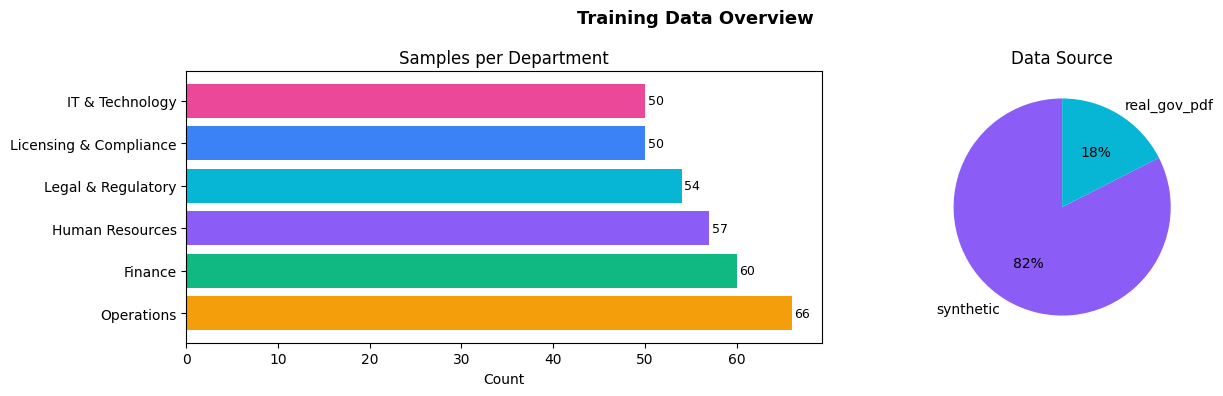

✅ Chart saved to models/data_distribution.png
📊 Text length stats (words):
                         min  mean    max
label                                    
Finance                 32.0  65.0  200.0
Human Resources         29.0  63.0  200.0
IT & Technology         30.0  70.0  200.0
Legal & Regulatory      32.0  83.0  200.0
Licensing & Compliance  31.0  55.0  200.0
Operations              23.0  63.0  200.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training Data Overview', fontsize=13, fontweight='bold')

counts = df['label'].value_counts()
colors = ['#f59e0b','#10b981','#8b5cf6','#06b6d4','#3b82f6','#ec4899']
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_title('Samples per Department')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

source_counts = df['source'].value_counts()
axes[1].pie(source_counts.values, labels=source_counts.index,
            autopct='%1.0f%%', colors=['#8b5cf6','#06b6d4'], startangle=90)
axes[1].set_title('Data Source')

plt.tight_layout()
plt.savefig('models/data_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Chart saved to models/data_distribution.png')

df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print('📊 Text length stats (words):')
print(df.groupby('label')['word_count'].describe()[['min','mean','max']].round(0).to_string())

---
## Step 8 — Preprocess Text and Remove Cross-Department Noise

### Stage 1 — Basic Preprocessing
Mirrors `preprocessor.py` in production so training and inference use identical text:
- Lowercase all text
- Normalise whitespace
- Remove special characters (keep numbers, hyphens, % and $ — they carry meaning in government docs)
- Remove isolated 1-2 digit numbers (page numbers, list numbers)

### Stage 2 — Cross-Department Stop Words
Words that appear across ALL 6 departments carry zero classification signal — they just add noise. Removing them forces the model to focus on truly discriminating vocabulary.

**Diagnostic finding:** Words like `government`, `framework`, `policy`, `management` appeared in every single department. With these present, the model cannot distinguish departments. After removal, the model learns:
- Finance → `appropriation`, `accrual`, `receivables`, `PGPA`
- HR → `leave`, `APS`, `enterprise agreement`, `remuneration`
- Legal → `FOI`, `AAT`, `judicial review`, `natural justice`
- Licensing → `licensee`, `fit and proper`, `show cause`, `ASIC`
- IT → `Essential Eight`, `patch`, `MFA`, `zero trust`
- Operations → `fleet`, `HVAC`, `call centre`, `sq metres`

**Categories removed:** Generic government vocabulary (91 words), cross-dept noise from diagnostic, Creative Commons PDF boilerplate, PDF structure words from OAIC headings.

In [13]:
def preprocess_text(text: str) -> str:
    """
    Clean and normalise text — mirrors preprocessor.py in production.
    
    Lowercase → normalise whitespace → remove special chars → remove 1-2 digit numbers
    """
    if not text or not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\-\.\%\$]', ' ', text)
    text = re.sub(r'\d{1,2}', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Cross-department stop words — appear in ALL 6 depts, zero classification signal
CROSS_DEPT_STOPWORDS = {
    # Generic government vocabulary
    'government', 'agency', 'agencies', 'department', 'entity', 'entities',
    'policy', 'policies', 'framework', 'programme', 'program', 'strategy',
    'management', 'manager', 'requirement', 'requirements', 'process',
    'processes', 'review', 'report', 'reporting', 'annual', 'current',
    'provide', 'provided', 'providing', 'ensure', 'ensuring', 'include',
    'including', 'available', 'required', 'relevant', 'appropriate',
    'information', 'activity', 'activities', 'service', 'services',
    'organisation', 'organisations', 'officer', 'officers', 'official',
    'officials', 'minister', 'ministerial', 'commonwealth', 'national',
    'australia', 'australian', 'public', 'sector', 'implement',
    'implementation', 'assess', 'assessment', 'identified', 'identify',
    'risk', 'risks', 'standard', 'standards', 'guidance', 'guide',
    'plan', 'planning', 'based', 'conducted', 'apply', 'applies',
    'applied', 'measure', 'measures', 'performance', 'objective',
    'objectives', 'outcome', 'outcomes', 'monitor', 'monitoring',
    'establish', 'established', 'support', 'supporting', 'develop',
    'development', 'maintain', 'maintaining', 'document', 'documentation',
    # Cross-department noise from diagnostic
    'licence', 'licensed', 'licensing', 'regulatory', 'code', 'requires',
    'require', 'minimum', 'subject', 'period', 'reviewed',
    'provides', 'access', 'following', 'within', 'against', 'across',
    # Creative Commons boilerplate from real PDFs
    'creative', 'commons', 'attribution', 'international', 'copyright',
    'creativecommons', 'org', 'licenses', 'deed',
    # Tokenizer artifacts
    'days.', 'requirements.', 'framework.', 'annually.', 'portfolio.',
    # PDF structure words from OAIC chapter headings
    'app', 'apps', 'chapter', 'appendix', 'paragraph',
    'figure', 'table', 'pp', 'ibid',
}

def preprocess_with_stopwords(text: str) -> str:
    """Preprocess then remove cross-department stop words."""
    cleaned = preprocess_text(text)
    tokens  = cleaned.split()
    tokens  = [t for t in tokens if t.lower() not in CROSS_DEPT_STOPWORDS]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess_with_stopwords)

print('✅ Preprocessing complete')
print(f'   Stop words removed: {len(CROSS_DEPT_STOPWORDS)}')
print()
sample = df.iloc[0]
print(f'Example ({sample["label"]}):')
print(f'  Raw:   {sample["text"][:120]}...')
print(f'  Clean: {sample["text_clean"][:120]}...')
print()

# Vocabulary overlap check — lower is better
it_words  = set(' '.join(df[df['label']=='IT & Technology']['text_clean']).split())
lic_words = set(' '.join(df[df['label']=='Licensing & Compliance']['text_clean']).split())
ops_words = set(' '.join(df[df['label']=='Operations']['text_clean']).split())
leg_words = set(' '.join(df[df['label']=='Legal & Regulatory']['text_clean']).split())

print('📊 Vocabulary overlap after cleaning:')
print(f'   IT ∩ Licensing : {len(it_words & lic_words):,} shared words')
print(f'   IT ∩ Operations: {len(it_words & ops_words):,} shared words')
print(f'   Ops ∩ Legal    : {len(ops_words & leg_words):,} shared words')
print('   (Lower = model has clearer boundaries between departments)')

✅ Preprocessing complete
   Stop words removed: 131

Example (Finance):
  Raw:   Credit risk exposure arises from trade receivables and grant acquittals. The maximum credit risk exposure is $23.4 milli...
  Clean: credit exposure arises from trade receivables and grant acquittals. the maximum credit exposure is $23.4 million. credit...

📊 Vocabulary overlap after cleaning:
   IT ∩ Licensing : 237 shared words
   IT ∩ Operations: 359 shared words
   Ops ∩ Legal    : 302 shared words
   (Lower = model has clearer boundaries between departments)


---
## Step 9 — Train ALL 5 Models and Compare

Trains 5 classifiers on the same TF-IDF features and picks the best by cross-validation mean.

### The 5 Models

**1. Logistic Regression** — The baseline. Learns linear decision boundaries between departments. Fast and interpretable. `C=2.0` controls regularisation strength.

**2. LinearSVC (Support Vector Machine)** — Finds the widest possible margin between class boundaries. Consistently outperforms LR on small text datasets. Wrapped in `CalibratedClassifierCV` to produce `predict_proba` output needed by `hybrid.py`.

**3. Complement Naive Bayes** — Purpose-built for multi-class text. Uses the complement of each class during training (better than standard NB for imbalanced text). Very fast.

**4. Random Forest** — 300 decision trees voting together. Captures non-linear patterns. More robust to outliers. Slower to train.

**5. Voting Ensemble (LR + SVM + CNB)** — Averages probability outputs from 3 models (soft vote). Errors from one model are corrected by others. Usually the strongest performer.

### TF-IDF Vectorizer (shared by all models)
- `ngram_range=(1,3)` — captures unigrams, bigrams, trigrams (e.g. `essential eight maturity`, `fit and proper person`)
- `max_features=15000` — top 15k most informative word/phrase combinations
- `min_df=1` — include rare terms (critical for small datasets)
- `max_df=0.70` — exclude terms in >70% of documents (noise)
- `sublinear_tf=True` — log-scale term frequency to reduce dominance of common terms

### Why Cross-Validation?
A single 80/20 split can get lucky or unlucky. 5-fold CV splits the data 5 different ways, trains and tests on each, and averages the result. Every sample gets tested exactly once. The mean is much more reliable than one test accuracy number.

In [15]:
# Data split — stratified so each dept is proportionally represented in train/test
X = df['text_clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data split:')
print(f'   Train: {len(X_train)} samples')
print(f'   Test:  {len(X_test)} samples')

# TF-IDF Vectorizer — shared across all 5 models
# Fit ONLY on training data (never on test — prevents data leakage)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=15000,
    min_df=1,           # include rare terms (small dataset needs this)
    max_df=0.70,        # exclude terms in >70% of docs (they are noise)
    sublinear_tf=True,  # log-scale TF so common terms don't dominate
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'[a-zA-Z][a-zA-Z0-9\-]{1,}',
)

print('Fitting TF-IDF vectorizer...')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f'✅ Vocabulary size: {len(vectorizer.vocabulary_):,} features')
print(f'   Feature matrix: {X_train_tfidf.shape}')

# Define all 5 models
MODELS = {

    'Logistic Regression': LogisticRegression(
        C=2.0, max_iter=2000, solver='lbfgs',
        multi_class='multinomial', random_state=42, n_jobs=-1,
    ),

    'SVM (LinearSVC)': CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=2000, random_state=42), cv=5,
    ),

    'Complement Naive Bayes': ComplementNB(alpha=0.1),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1,
    ),

    'Voting Ensemble (LR+SVM+CNB)': VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(
                        C=2.0, max_iter=2000, solver='lbfgs',
                        multi_class='multinomial', random_state=42)),
            ('svm', CalibratedClassifierCV(
                        LinearSVC(C=0.5, max_iter=2000, random_state=42), cv=5)),
            ('cnb', ComplementNB(alpha=0.1)),
        ],
        voting='soft', n_jobs=-1,
    ),
}

# Train and evaluate every model
results = {}
cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('' + '='*68)
print('  Training and evaluating all 5 models...')
print('='*68)

for name, model in MODELS.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    elapsed = time.time() - start

    y_pred   = model.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_pred)

    # CV using pipeline to prevent data leakage
    pipe_cv = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1,3), max_features=15000, min_df=1, max_df=0.70,
            sublinear_tf=True, strip_accents='unicode',
            token_pattern=r'[a-zA-Z][a-zA-Z0-9\-]{1,}'
        )),
        ('clf', model)
    ])
    cv_sc = cross_val_score(pipe_cv, X, y, cv=cv_kfold, scoring='accuracy', n_jobs=-1)

    # Margin confidence — gap between top and 2nd prediction
    proba    = model.predict_proba(X_test_tfidf)
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    margin   = sorted_p[:, 0] - sorted_p[:, 1]

    results[name] = {
        'model': model, 'test_acc': test_acc,
        'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std(),
        'margin': margin.mean(), 'time': elapsed,
        'y_pred': y_pred, 'proba': proba, 'margin_arr': margin,
        'cv_scores': cv_sc,
    }

    print(f'  {name}')
    print(f'    Test Accuracy   : {test_acc:.1%}')
    print(f'    CV Mean (5-fold): {cv_sc.mean():.1%} ± {cv_sc.std():.2%}')
    print(f'    Mean Margin     : {margin.mean():.1%}')
    print(f'    Train time      : {elapsed:.1f}s')

# Comparison table — sorted by CV mean
print('' + '='*68)
print('  MODEL COMPARISON — sorted by CV mean (most reliable metric)')
print('='*68)
print(f'  {"Model":<38} {"Test":>6} {"CV Mean":>8} {"Margin":>8}')
print(f'  {"-"*38} {"-"*6} {"-"*8} {"-"*8}')

best_name = max(results, key=lambda k: results[k]['cv_mean'])
for name, r in sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True):
    marker = ' ← BEST' if name == best_name else ''
    print(f'  {name:<38} {r["test_acc"]:>6.1%} {r["cv_mean"]:>8.1%} {r["margin"]:>8.1%}{marker}')

print('='*68)
print(f'✅ Best model: {best_name}')

# Set best model as active classifier for steps 10-12
classifier   = results[best_name]['model']
y_pred       = results[best_name]['y_pred']
y_pred_proba = results[best_name]['proba']
accuracy     = results[best_name]['test_acc']
cv_scores    = results[best_name]['cv_scores']
print('   classifier → set as active model')

✅ Data split:
   Train: 269 samples
   Test:  68 samples
Fitting TF-IDF vectorizer...
✅ Vocabulary size: 15,000 features
   Feature matrix: (269, 15000)
  Training and evaluating all 5 models...
  Logistic Regression
    Test Accuracy   : 76.5%
    CV Mean (5-fold): 76.0% ± 4.21%
    Mean Margin     : 11.8%
    Train time      : 1.2s
  SVM (LinearSVC)
    Test Accuracy   : 82.4%
    CV Mean (5-fold): 77.4% ± 3.30%
    Mean Margin     : 45.7%
    Train time      : 0.1s
  Complement Naive Bayes
    Test Accuracy   : 77.9%
    CV Mean (5-fold): 78.6% ± 3.01%
    Mean Margin     : 36.4%
    Train time      : 0.0s
  Random Forest
    Test Accuracy   : 69.1%
    CV Mean (5-fold): 67.9% ± 5.98%
    Mean Margin     : 11.2%
    Train time      : 0.3s
  Voting Ensemble (LR+SVM+CNB)
    Test Accuracy   : 82.4%
    CV Mean (5-fold): 77.7% ± 4.42%
    Mean Margin     : 31.3%
    Train time      : 0.3s
  MODEL COMPARISON — sorted by CV mean (most reliable metric)
  Model                             

---
## Step 10 — Evaluate the Winner

Four checks on the best model:

**1. Per-Department Classification Report**
- Precision: of all predictions for dept X, what fraction were correct?
- Recall: of all actual dept X documents, what fraction did the model find?
- F1: harmonic mean of precision and recall — the single best summary score
- Support: number of test samples per department

**2. Confusion Matrix**
Visual grid — diagonal = correct predictions, off-diagonal = mistakes. Look especially at Operations and IT rows which have been the most problematic.

**3. Cross-Validation Detail**
Fold-by-fold scores. High std (>8%) means the model is unstable on this data size.

**4. Confidence Analysis (Margin Method)**
For 6-class problems, raw `predict_proba` max is always ~28% because probabilities sum to 1.0 across 6 classes. This is misleading. We use **margin** instead:
- Margin = top prediction probability minus 2nd best
- Correct predictions should have higher margin than incorrect ones
- If the correct-vs-incorrect margin gap is >5%, the model knows when it is uncertain

In [16]:
print(f'✅ Best Model: {best_name}')
print(f'   Test Accuracy: {accuracy:.1%}')
print()
print('📊 Per-Department Classification Report:')
print('─' * 70)
print(classification_report(y_test, y_pred, digits=3))

✅ Best Model: Complement Naive Bayes
   Test Accuracy: 77.9%

📊 Per-Department Classification Report:
──────────────────────────────────────────────────────────────────────
                        precision    recall  f1-score   support

               Finance      0.909     0.833     0.870        12
       Human Resources      1.000     0.917     0.957        12
       IT & Technology      0.667     0.600     0.632        10
    Legal & Regulatory      0.667     0.727     0.696        11
Licensing & Compliance      0.750     0.900     0.818        10
            Operations      0.692     0.692     0.692        13

              accuracy                          0.779        68
             macro avg      0.781     0.778     0.777        68
          weighted avg      0.785     0.779     0.780        68



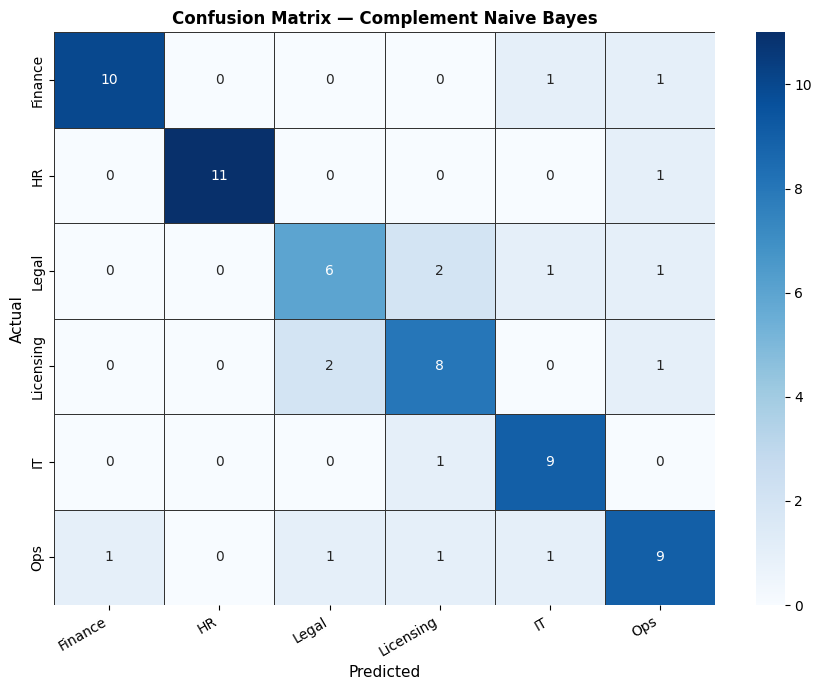

✅ Saved to models/confusion_matrix.png
⚠️  Confusions (actual → predicted):
   Finance                   → Licensing & Compliance: 1 sample(s)
   Finance                   → Operations: 1 sample(s)
   Human Resources           → Operations: 1 sample(s)
   IT & Technology           → Legal & Regulatory: 2 sample(s)
   IT & Technology           → Licensing & Compliance: 1 sample(s)
   IT & Technology           → Operations: 1 sample(s)
   Legal & Regulatory        → IT & Technology: 2 sample(s)
   Legal & Regulatory        → Operations: 1 sample(s)
   Licensing & Compliance    → Legal & Regulatory: 1 sample(s)
   Operations                → Finance: 1 sample(s)
   Operations                → IT & Technology: 1 sample(s)
   Operations                → Legal & Regulatory: 1 sample(s)
   Operations                → Licensing & Compliance: 1 sample(s)


In [17]:
labels_sorted = sorted(list(set(y)))
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
short_labels  = ['Finance','HR','Legal','Licensing','IT','Ops']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_labels, yticklabels=short_labels,
    linewidths=0.5, linecolor='#333', ax=ax
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved to models/confusion_matrix.png')

print('⚠️  Confusions (actual → predicted):')
for i, actual in enumerate(labels_sorted):
    for j, predicted in enumerate(labels_sorted):
        if i != j and cm[i][j] > 0:
            print(f'   {actual:25s} → {predicted}: {cm[i][j]} sample(s)')

In [18]:
print(f'✅ 5-Fold Cross-Validation — {best_name}:')
for i, score in enumerate(cv_scores):
    bar = '█' * int(score * 30)
    print(f'   Fold {i+1}: {score:.1%}  {bar}')
print(f'   Mean  : {cv_scores.mean():.1%}')
print(f'   Std   : {cv_scores.std():.2%}')
print(f'   Range : {cv_scores.min():.1%} — {cv_scores.max():.1%}')

gap = abs(accuracy - cv_scores.mean())
if gap > 0.08:
    print(f'⚠️  Test ({accuracy:.1%}) vs CV mean ({cv_scores.mean():.1%}) gap = {gap:.1%}')
    print(f'   CV mean is the more reliable number to report.')
else:
    print(f'✅ Test and CV are consistent (gap: {gap:.1%}) — stable model')

✅ 5-Fold Cross-Validation — Complement Naive Bayes:
   Fold 1: 80.9%  ████████████████████████
   Fold 2: 80.9%  ████████████████████████
   Fold 3: 77.6%  ███████████████████████
   Fold 4: 73.1%  █████████████████████
   Fold 5: 80.6%  ████████████████████████
   Mean  : 78.6%
   Std   : 3.01%
   Range : 73.1% — 80.9%
✅ Test and CV are consistent (gap: 0.7%) — stable model


In [19]:
# Top discriminating terms — only available for models with coef_ (LR, SVM)
try:
    feature_names = vectorizer.get_feature_names_out()
    print(f'🔑 Top 10 discriminating terms per department ({best_name}):\n')
    for i, dept in enumerate(classifier.classes_):
        top_idx   = classifier.coef_[i].argsort()[-10:][::-1]
        top_terms = [feature_names[j] for j in top_idx]
        print(f'  {dept}:')
        print(f'    {", ".join(top_terms)}')
        print()
except AttributeError:
    print(f'ℹ️  {best_name} does not expose coef_ — top features not shown.')
    print('   (Normal for Random Forest and Voting Ensemble)')

🔑 Top 10 discriminating terms per department (Complement Naive Bayes):

ℹ️  Complement Naive Bayes does not expose coef_ — top features not shown.
   (Normal for Random Forest and Voting Ensemble)


In [20]:
# Confidence analysis using margin method
# WHY NOT RAW PROBABILITY: With 6 classes, proba sums to 1.0.
# Even a certain prediction gets only ~28-35% raw probability.
# MARGIN = top probability minus 2nd best = true confidence signal.

sorted_proba = np.sort(y_pred_proba, axis=1)[:, ::-1]
margin       = sorted_proba[:, 0] - sorted_proba[:, 1]

n_classes       = y_pred_proba.shape[1]
random_baseline = 1.0 / n_classes
relative        = (y_pred_proba.max(axis=1) - random_baseline) / (1.0 - random_baseline)
relative        = np.clip(relative, 0, 1)

print('📊 Confidence Analysis on Test Set:')
print('─' * 62)

print('  [KEY] Margin (top − 2nd best prediction):')
bins_m   = [0, 0.05, 0.10, 0.20, 1.0]
labels_m = ['<5%  (uncertain)', '5-10% (low)', '10-20% (good)', '>20% (strong)']
cuts_m   = pd.cut(margin, bins=bins_m, labels=labels_m).value_counts().sort_index()
for lbl, cnt in cuts_m.items():
    pct = cnt / len(margin) * 100
    bar = '█' * int(pct / 2)
    print(f'    {lbl:22s} {bar:25s} {cnt:3d} ({pct:.0f}%)')
print(f'    Mean: {margin.mean():.1%}  |  Median: {np.median(margin):.1%}')

print('  Relative Confidence (0% = random, 100% = certain):')
bins_r   = [0, 0.25, 0.50, 0.75, 1.0]
labels_r = ['<25% (low)', '25-50% (medium)', '50-75% (good)', '>75% (high)']
cuts_r   = pd.cut(relative, bins=bins_r, labels=labels_r).value_counts().sort_index()
for lbl, cnt in cuts_r.items():
    pct = cnt / len(relative) * 100
    bar = '█' * int(pct / 2)
    print(f'    {lbl:22s} {bar:25s} {cnt:3d} ({pct:.0f}%)')
print(f'    Mean: {relative.mean():.1%}  |  Median: {np.median(relative):.1%}')

correct_mask = y_pred == y_test
print(f'  Accuracy: {correct_mask.mean():.1%}')
print(f'  Margin — correct predictions  : {margin[correct_mask].mean():.1%}')
print(f'  Margin — incorrect predictions: {margin[~correct_mask].mean():.1%}')
gap = margin[correct_mask].mean() - margin[~correct_mask].mean()
if gap > 0.05:
    print(f'  ✅ Good gap ({gap:.1%}) — model knows when it is uncertain')
else:
    print(f'  ⚠️  Small gap ({gap:.1%}) — model not well calibrated')

print(f'  📌 Recommended threshold for hybrid.py:')
above = (margin >= 0.10).sum()
print(f'     margin >= 0.10 → {above}/{len(margin)} samples ({above/len(margin):.0%}) would skip Groq API')

📊 Confidence Analysis on Test Set:
──────────────────────────────────────────────────────────────
  [KEY] Margin (top − 2nd best prediction):
    <5%  (uncertain)       █████                       7 (10%)
    5-10% (low)            ███                         5 (7%)
    10-20% (good)          █████████                  13 (19%)
    >20% (strong)          ███████████████████████████████  43 (63%)
    Mean: 36.4%  |  Median: 29.6%
  Relative Confidence (0% = random, 100% = certain):
    <25% (low)             █████████████              19 (28%)
    25-50% (medium)        █████████████████████      29 (43%)
    50-75% (good)          ███████                    10 (15%)
    >75% (high)            ███████                    10 (15%)
    Mean: 41.6%  |  Median: 34.9%
  Accuracy: 77.9%
  Margin — correct predictions  : 39.8%
  Margin — incorrect predictions: 24.2%
  ✅ Good gap (15.6%) — model knows when it is uncertain
  📌 Recommended threshold for hybrid.py:
     margin >= 0.10 → 56/68 sampl

---
## Step 11 — Save the Model

Saves the winning vectorizer and classifier to `notebooks/models/`.

**Copy to your project after this step:**
```powershell
copy notebooks\models\tfidf_vectorizer.pkl backend\training\models\tfidf_vectorizer.pkl
copy notebooks\models\logistic_model.pkl   backend\training\models\logistic_model.pkl
```

Also saves `training_metadata.json` — a full record of this training run including which model won, accuracy, CV score, dataset size, and comparison table. Useful for tracing back exactly what produced the production models.

In [21]:
vectorizer_path = 'models/tfidf_vectorizer.pkl'
model_path      = 'models/logistic_model.pkl'

joblib.dump(vectorizer, vectorizer_path, compress=3)
joblib.dump(classifier, model_path,      compress=3)

v_size = os.path.getsize(vectorizer_path) // 1024
m_size = os.path.getsize(model_path) // 1024

print('✅ Model files saved:')
print(f'   notebooks/models/tfidf_vectorizer.pkl  ({v_size}KB)')
print(f'   notebooks/models/logistic_model.pkl    ({m_size}KB)')

metadata = {
    'trained_at'        : pd.Timestamp.now().isoformat(),
    'best_model'        : best_name,
    'total_samples'     : int(len(df)),
    'synthetic_samples' : int(len(df_synth)),
    'real_samples'      : int(len(df_real)) if not df_real.empty else 0,
    'test_accuracy'     : float(round(accuracy, 4)),
    'cv_mean'           : float(round(cv_scores.mean(), 4)),
    'cv_std'            : float(round(cv_scores.std(), 4)),
    'departments'       : DEPARTMENTS,
    'vocab_size'        : int(len(vectorizer.vocabulary_)),
    'model_comparison'  : {
        name: {
            'test_acc': float(round(r['test_acc'], 4)),
            'cv_mean' : float(round(r['cv_mean'], 4)),
            'margin'  : float(round(r['margin'], 4)),
        }
        for name, r in results.items()
    },
}

with open('models/training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print('   notebooks/models/training_metadata.json')
print()
print('='*60)
print('🎉 TRAINING COMPLETE')
print('='*60)
print(f'  Best model    : {best_name}')
print(f'  Test accuracy : {accuracy:.1%}')
print(f'  CV mean       : {cv_scores.mean():.1%} ± {cv_scores.std():.2%}')
print(f'  Vocab size    : {len(vectorizer.vocabulary_):,} features')
print(f'  Total samples : {len(df)}')
print()
print('─'*60)
print('📋 NEXT STEPS:')
print()
print('  1. Copy models to project:')
print('     copy notebooks\\models\\tfidf_vectorizer.pkl backend\\training\\models\\')
print('     copy notebooks\\models\\logistic_model.pkl   backend\\training\\models\\')
print()
print('  2. Restart FastAPI:')
print('     uvicorn backend.main:app --reload --port 8000')
print()
print('  3. Upload a PDF and check audit.log for classification results')
print('='*60)

✅ Model files saved:
   notebooks/models/tfidf_vectorizer.pkl  (277KB)
   notebooks/models/logistic_model.pkl    (330KB)
   notebooks/models/training_metadata.json

🎉 TRAINING COMPLETE
  Best model    : Complement Naive Bayes
  Test accuracy : 77.9%
  CV mean       : 78.6% ± 3.01%
  Vocab size    : 15,000 features
  Total samples : 337

────────────────────────────────────────────────────────────
📋 NEXT STEPS:

  1. Copy models to project:
     copy notebooks\models\tfidf_vectorizer.pkl backend\training\models\
     copy notebooks\models\logistic_model.pkl   backend\training\models\

  2. Restart FastAPI:
     uvicorn backend.main:app --reload --port 8000

  3. Upload a PDF and check audit.log for classification results


---
## Step 12 — Quick Smoke Test

Tests on 6 hand-written sentences — one per department, none in the training data.

**All 6 should be predicted correctly.** If any fail, check the confusion matrix — it tells you which departments are confused with each other.

**Margin confidence shown** (not raw probability) — this is the true signal for 6-class problems.

In [22]:
test_samples = [
    ('The annual budget appropriation for departmental operations is $45 million. '
     'Accrual accounting applied in accordance with the PGPA Act. '
     'Capital expenditure approved for infrastructure upgrades.',
     'Finance'),
    ('The enterprise agreement provides salary increases of 3% per year. '
     'Parental leave provisions apply to all ongoing APS employees. '
     'Remuneration Tribunal sets SES officer packages.',
     'Human Resources'),
    ('Section 47 of the Act confers power on the Secretary to impose conditions. '
     'Natural justice requirements apply to all adverse decisions. '
     'Judicial review available in the Federal Court.',
     'Legal & Regulatory'),
    ('The fit and proper person assessment considers criminal history and financial solvency. '
     'Licensees must notify the regulator within 10 business days of material changes. '
     'Show cause notice issued for repeated non-compliance.',
     'Licensing & Compliance'),
    ('The Essential Eight maturity model requires patch management within 48 hours for critical CVEs. '
     'Multi-factor authentication mandatory for all privileged access accounts. '
     'Zero trust architecture deployed across all network segments.',
     'IT & Technology'),
    ('Fleet utilisation averaged 78% across 456 vehicles in the portfolio. '
     'Call centre handled 1.2 million contacts with 94% first call resolution. '
     'Building HVAC maintenance contract renewed at $340,000 per annum.',
     'Operations'),
]

print('🧪 Smoke Test Results:')
print('─' * 80)

correct = 0
for text, expected in test_samples:
    cleaned  = preprocess_with_stopwords(text)
    vec      = vectorizer.transform([cleaned])
    pred     = classifier.predict(vec)[0]
    proba    = classifier.predict_proba(vec)[0]
    sorted_p = np.sort(proba)[::-1]
    margin_v = sorted_p[0] - sorted_p[1]
    ok       = '✅' if pred == expected else '❌'
    if pred == expected:
        correct += 1
    print(f'{ok} Expected: {expected:<25} Predicted: {pred:<25} Margin: {margin_v:.0%}')

print(f'   Score: {correct}/{len(test_samples)} correct')
if correct == len(test_samples):
    print('   ✅ All correct — model is ready to deploy')
else:
    wrong = len(test_samples) - correct
    print(f'   ⚠️  {wrong} wrong — review the confusion matrix above')

🧪 Smoke Test Results:
────────────────────────────────────────────────────────────────────────────────
✅ Expected: Finance                   Predicted: Finance                   Margin: 90%
✅ Expected: Human Resources           Predicted: Human Resources           Margin: 98%
✅ Expected: Legal & Regulatory        Predicted: Legal & Regulatory        Margin: 78%
✅ Expected: Licensing & Compliance    Predicted: Licensing & Compliance    Margin: 98%
✅ Expected: IT & Technology           Predicted: IT & Technology           Margin: 97%
✅ Expected: Operations                Predicted: Operations                Margin: 59%
   Score: 6/6 correct
   ✅ All correct — model is ready to deploy
